In [2]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

EAR_IZQ = [33, 160, 158, 133, 153, 144]
EAR_DER = [362, 385, 387, 263, 373, 380]
BOCA = {"izq": 61, "der": 291, "sup_ext": 13, "inf_ext": 14, "sup1": 82, "inf1": 312, "sup2": 87, "inf2": 317}

def calcular_ear_un_ojo(landmarks, indices, w, h):
    p = [np.array([landmarks[i].x*w, landmarks[i].y*h]) for i in indices]
    vertical = (np.linalg.norm(p[1]-p[5]) + np.linalg.norm(p[2]-p[4])) / 2
    horizontal = np.linalg.norm(p[0]-p[3])
    return vertical / horizontal

def calcular_mar(landmarks, w, h):
    def punto(idx): return np.array([landmarks[idx].x*w, landmarks[idx].y*h])
    horizontal = np.linalg.norm(punto(BOCA["izq"]) - punto(BOCA["der"]))
    v1 = np.linalg.norm(punto(BOCA["sup_ext"]) - punto(BOCA["inf_ext"]))
    v2 = np.linalg.norm(punto(BOCA["sup1"]) - punto(BOCA["inf1"]))
    v3 = np.linalg.norm(punto(BOCA["sup2"]) - punto(BOCA["inf2"]))
    return (v1+v2+v3) / (3*horizontal)

print("Funciones listas.")

Funciones listas.


In [3]:
opts = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="../models/face_landmarker.task"),
    running_mode=RunningMode.IMAGE, num_faces=1)
detector = FaceLandmarker.create_from_options(opts)
print("MediaPipe cargado.")

MediaPipe cargado.


In [4]:
def xml_a_vector(ruta_xml, etiqueta, total_frames):
    tree = ET.parse(ruta_xml)
    vector = np.zeros(total_frames, dtype=int)
    for track in tree.getroot().findall(".//track"):
        if track.get("label") != etiqueta: 
            continue
        boxes = track.findall("box")
        inicio, fin = int(boxes[0].get("frame")), int(boxes[-1].get("frame"))
        vector[inicio:fin+1] = 1
    return vector

print("Función lista.")

Función lista.


In [5]:
filas = []
for nombre in ["calibracion_C1", "calibracion_C2", "calibracion_C3"]:
    ruta_video = next(Path("../data/raw").glob(f"{nombre}.*"))
    cap = cv2.VideoCapture(str(ruta_video))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"{nombre}: {fps:.1f} FPS, {total_frames} frames")

    v_cierre = xml_a_vector(f"../data/labeled/{nombre}.xml", "cierre_ocular", total_frames)
    v_bostezo = xml_a_vector(f"../data/labeled/{nombre}.xml", "bostezo", total_frames)

    n = 0
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok: 
            break
        h, w = frame.shape[:2]
        img_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        res = detector.detect(img_mp)
        if len(res.face_landmarks) > 0:
            lm = res.face_landmarks[0]
            ear = (calcular_ear_un_ojo(lm, EAR_IZQ, w, h) + calcular_ear_un_ojo(lm, EAR_DER, w, h)) / 2
            mar = calcular_mar(lm, w, h)
            filas.append({"persona": nombre, "frame": n, "ear": ear, "mar": mar,
                          "cierre_real": v_cierre[n] if n < len(v_cierre) else 0,
                          "bostezo_real": v_bostezo[n] if n < len(v_bostezo) else 0})
        n += 1
    cap.release()
    print(f"  -> {nombre} procesado")

df_calibracion = pd.DataFrame(filas)
Path("../results").mkdir(exist_ok=True)
df_calibracion.to_csv("../results/calibracion_ear_mar.csv", index=False)
print(f"\nTotal fotogramas procesados: {len(df_calibracion)}")

calibracion_C1: 30.0 FPS, 3627 frames
  -> calibracion_C1 procesado
calibracion_C2: 60.0 FPS, 6144 frames
  -> calibracion_C2 procesado
calibracion_C3: 30.0 FPS, 2956 frames
  -> calibracion_C3 procesado

Total fotogramas procesados: 12727


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

df_calibracion = pd.read_csv("../results/calibracion_ear_mar.csv")
print("Filas cargadas:", len(df_calibracion))
print(df_calibracion.head())

Filas cargadas: 12727
          persona  frame       ear       mar  cierre_real  bostezo_real
0  calibracion_C1      0  0.237728  0.155335            0             0
1  calibracion_C1      1  0.248349  0.157409            0             0
2  calibracion_C1      2  0.243653  0.156482            0             0
3  calibracion_C1      3  0.242168  0.156035            0             0
4  calibracion_C1      4  0.240883  0.156920            0             0


In [5]:
print("Distribución de clases para EAR (cierre ocular):")
print(df_calibracion["cierre_real"].value_counts())
print(f"Proporción de fotogramas con cierre: {df_calibracion['cierre_real'].mean()*100:.2f}%")

print("\nDistribución de clases para MAR (bostezo):")
print(df_calibracion["bostezo_real"].value_counts())
print(f"Proporción de fotogramas con bostezo: {df_calibracion['bostezo_real'].mean()*100:.2f}%")

print("\nEstadísticas descriptivas de EAR por estado:")
print(df_calibracion.groupby("cierre_real")["ear"].describe())

print("\nEstadísticas descriptivas de MAR por estado:")
print(df_calibracion.groupby("bostezo_real")["mar"].describe())

Distribución de clases para EAR (cierre ocular):
cierre_real
0    10551
1     2176
Name: count, dtype: int64
Proporción de fotogramas con cierre: 17.10%

Distribución de clases para MAR (bostezo):
bostezo_real
0    11323
1     1404
Name: count, dtype: int64
Proporción de fotogramas con bostezo: 11.03%

Estadísticas descriptivas de EAR por estado:
               count      mean       std       min       25%       50%  \
cierre_real                                                              
0            10551.0  0.236674  0.072808  0.013439  0.213637  0.251711   
1             2176.0  0.079164  0.037992  0.025439  0.058088  0.069022   

                  75%       max  
cierre_real                      
0            0.296551  0.335612  
1            0.085281  0.302548  

Estadísticas descriptivas de MAR por estado:
                count      mean       std       min       25%       50%  \
bostezo_real                                                              
0             11323.0 

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

def umbral_youden(y_true, score, menor_es_positivo=True):
    """
    Para EAR: valores BAJOS indican cierre de ojo (evento positivo), así que invertimos el signo
    para que roc_curve trate 'score alto' como 'más probable positivo', que es su convención estándar.
    Para MAR: valores ALTOS indican bostezo (evento positivo), se usa tal cual.
    """
    s = -score if menor_es_positivo else score
    fpr, tpr, umbrales = roc_curve(y_true, s)
    youden = tpr - fpr
    idx_mejor = np.argmax(youden)
    umbral_final = -umbrales[idx_mejor] if menor_es_positivo else umbrales[idx_mejor]
    sensibilidad = tpr[idx_mejor]
    especificidad = 1 - fpr[idx_mejor]
    auc = roc_auc_score(y_true, s)
    return umbral_final, youden[idx_mejor], sensibilidad, especificidad, auc

umbral_ear, j_ear, sens_ear, espec_ear, auc_ear = umbral_youden(
    df_calibracion["cierre_real"], df_calibracion["ear"], menor_es_positivo=True)

umbral_mar, j_mar, sens_mar, espec_mar, auc_mar = umbral_youden(
    df_calibracion["bostezo_real"], df_calibracion["mar"], menor_es_positivo=False)

print("=== EAR (cierre ocular) ===")
print(f"Umbral óptimo: {umbral_ear:.4f}")
print(f"Índice de Youden: {j_ear:.3f}")
print(f"Sensibilidad: {sens_ear:.3f} | Especificidad: {espec_ear:.3f}")
print(f"AUC-ROC: {auc_ear:.3f}")

print("\n=== MAR (bostezo) ===")
print(f"Umbral óptimo: {umbral_mar:.4f}")
print(f"Índice de Youden: {j_mar:.3f}")
print(f"Sensibilidad: {sens_mar:.3f} | Especificidad: {espec_mar:.3f}")
print(f"AUC-ROC: {auc_mar:.3f}")

=== EAR (cierre ocular) ===
Umbral óptimo: 0.1404
Índice de Youden: 0.816
Sensibilidad: 0.931 | Especificidad: 0.885
AUC-ROC: 0.928

=== MAR (bostezo) ===
Umbral óptimo: 0.1624
Índice de Youden: 0.933
Sensibilidad: 0.959 | Especificidad: 0.974
AUC-ROC: 0.985


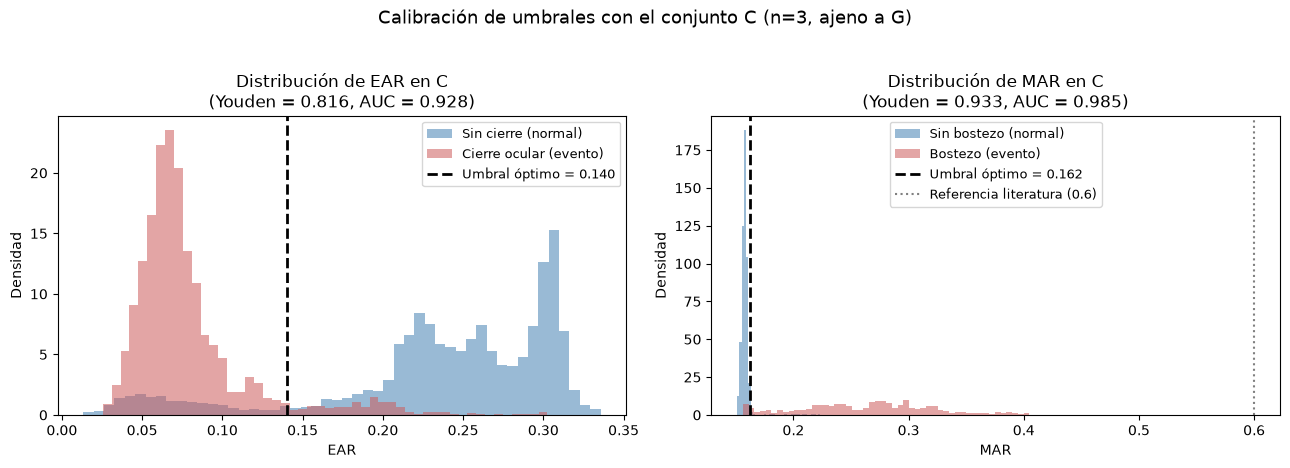

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel EAR
ax = axes[0]
ax.hist(df_calibracion[df_calibracion["cierre_real"]==0]["ear"], bins=50, alpha=0.55,
        label="Sin cierre (normal)", color="steelblue", density=True)
ax.hist(df_calibracion[df_calibracion["cierre_real"]==1]["ear"], bins=50, alpha=0.55,
        label="Cierre ocular (evento)", color="indianred", density=True)
ax.axvline(umbral_ear, color="black", linestyle="--", linewidth=2,
           label=f"Umbral óptimo = {umbral_ear:.3f}")
ax.set_title(f"Distribución de EAR en C\n(Youden = {j_ear:.3f}, AUC = {auc_ear:.3f})")
ax.set_xlabel("EAR")
ax.set_ylabel("Densidad")
ax.legend(fontsize=9)

# Panel MAR
ax = axes[1]
ax.hist(df_calibracion[df_calibracion["bostezo_real"]==0]["mar"], bins=50, alpha=0.55,
        label="Sin bostezo (normal)", color="steelblue", density=True)
ax.hist(df_calibracion[df_calibracion["bostezo_real"]==1]["mar"], bins=50, alpha=0.55,
        label="Bostezo (evento)", color="indianred", density=True)
ax.axvline(umbral_mar, color="black", linestyle="--", linewidth=2,
           label=f"Umbral óptimo = {umbral_mar:.3f}")
ax.axvline(0.6, color="gray", linestyle=":", linewidth=1.5,
           label="Referencia literatura (0.6)")
ax.set_title(f"Distribución de MAR en C\n(Youden = {j_mar:.3f}, AUC = {auc_mar:.3f})")
ax.set_xlabel("MAR")
ax.set_ylabel("Densidad")
ax.legend(fontsize=9)

plt.suptitle("Calibración de umbrales con el conjunto C (n=3, ajeno a G)", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("../results/fig_calibracion_ear_mar.png", dpi=150, bbox_inches="tight")
plt.show()

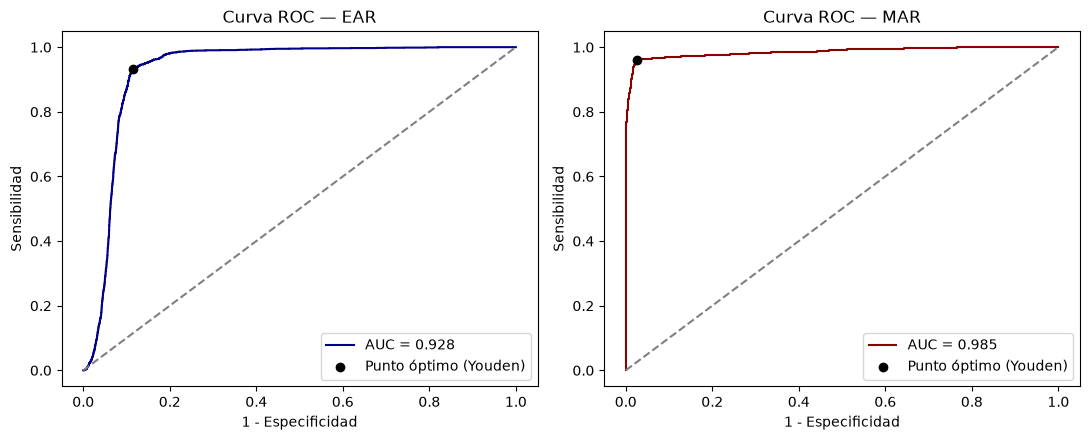

In [8]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr_ear, tpr_ear, _ = roc_curve(df_calibracion["cierre_real"], -df_calibracion["ear"])
axes[0].plot(fpr_ear, tpr_ear, color="darkblue", label=f"AUC = {auc_ear:.3f}")
axes[0].plot([0,1],[0,1], linestyle="--", color="gray")
axes[0].scatter([1-espec_ear], [sens_ear], color="black", zorder=5, label="Punto óptimo (Youden)")
axes[0].set_title("Curva ROC — EAR")
axes[0].set_xlabel("1 - Especificidad"); axes[0].set_ylabel("Sensibilidad")
axes[0].legend()

fpr_mar, tpr_mar, _ = roc_curve(df_calibracion["bostezo_real"], df_calibracion["mar"])
axes[1].plot(fpr_mar, tpr_mar, color="darkred", label=f"AUC = {auc_mar:.3f}")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray")
axes[1].scatter([1-espec_mar], [sens_mar], color="black", zorder=5, label="Punto óptimo (Youden)")
axes[1].set_title("Curva ROC — MAR")
axes[1].set_xlabel("1 - Especificidad"); axes[1].set_ylabel("Sensibilidad")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/fig_roc_calibracion.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
df_umbrales = pd.DataFrame({
    "indicador": ["EAR", "MAR"],
    "umbral_calibrado": [round(umbral_ear, 4), round(umbral_mar, 4)],
    "indice_youden": [round(j_ear, 3), round(j_mar, 3)],
    "sensibilidad": [round(sens_ear, 3), round(sens_mar, 3)],
    "especificidad": [round(espec_ear, 3), round(espec_mar, 3)],
    "auc_roc": [round(auc_ear, 3), round(auc_mar, 3)],
    "n_personas_C": [3, 3],
    "total_fotogramas_C": [len(df_calibracion), len(df_calibracion)],
})
df_umbrales.to_csv("../results/umbrales_calibrados.csv", index=False)
print(df_umbrales.to_string(index=False))
print("\nGuardado en results/umbrales_calibrados.csv")

indicador  umbral_calibrado  indice_youden  sensibilidad  especificidad  auc_roc  n_personas_C  total_fotogramas_C
      EAR            0.1404          0.816         0.931          0.885    0.928             3               12727
      MAR            0.1624          0.933         0.959          0.974    0.985             3               12727

Guardado en results/umbrales_calibrados.csv


In [10]:
from pathlib import Path

# Rutas principales
RUTA_MODELOS = Path("../models")
RUTA_RAW = Path("../data/raw")
RUTA_LABELED = Path("../data/labeled")
RUTA_RESULTS = Path("../results")

print("=== MODELOS ONNX ===")
for p in sorted(RUTA_MODELOS.glob("*.onnx")):
    print(p.name)

print("\n=== ARCHIVOS DE CALIBRACIÓN C ===")
for p in sorted(RUTA_RAW.glob("C*")):
    print(p.name)

print("\n=== ARCHIVOS RELACIONADOS CON CALIBRACIÓN EN RESULTS ===")
for p in sorted(RUTA_RESULTS.glob("*calibr*")):
    print(p.name)

=== MODELOS ONNX ===
mobilenetv2_ojos.onnx
mobilenetv2_ojos_v2.onnx
mobilenetv2_yawn.onnx
mobilenetv2_yawn_dedup.onnx

=== ARCHIVOS DE CALIBRACIÓN C ===
calibracion_C1.mp4
calibracion_C2.mp4
calibracion_C3.mp4

=== ARCHIVOS RELACIONADOS CON CALIBRACIÓN EN RESULTS ===
calibracion_ear_mar.csv
fig_calibracion_ear_mar.png
fig_roc_calibracion.png
umbrales_calibrados.csv


In [11]:
from pathlib import Path
import pandas as pd

RUTA_RESULTS = Path("../results")
RUTA_LABELED = Path("../data/labeled")

# =========================
# 1. Revisar CSV de calibración
# =========================
ruta_calib = RUTA_RESULTS / "calibracion_ear_mar.csv"

df_calib = pd.read_csv(ruta_calib)

print("=== COLUMNAS DE calibracion_ear_mar.csv ===")
print(df_calib.columns.tolist())

print("\n=== DIMENSIONES ===")
print(df_calib.shape)

print("\n=== PRIMERAS 5 FILAS ===")
display(df_calib.head())

print("\n=== TIPOS DE DATOS ===")
print(df_calib.dtypes)

# =========================
# 2. Buscar archivos de C en labeled
# =========================
print("\n=== ARCHIVOS DE CALIBRACIÓN EN data/labeled ===")

archivos_c = sorted([
    p for p in RUTA_LABELED.iterdir()
    if "C1" in p.name.upper()
    or "C2" in p.name.upper()
    or "C3" in p.name.upper()
    or "CALIBRACION" in p.name.upper()
])

for p in archivos_c:
    print(p.name)

print("\nCantidad:", len(archivos_c))

=== COLUMNAS DE calibracion_ear_mar.csv ===
['persona', 'frame', 'ear', 'mar', 'cierre_real', 'bostezo_real']

=== DIMENSIONES ===
(12727, 6)

=== PRIMERAS 5 FILAS ===


,persona,frame,ear,mar,cierre_real,bostezo_real
0,calibracion_C1,0,0.237728,0.155335,0,0
1,calibracion_C1,1,0.248349,0.157409,0,0
2,calibracion_C1,2,0.243653,0.156482,0,0
3,calibracion_C1,3,0.242168,0.156035,0,0
4,calibracion_C1,4,0.240883,0.156920,0,0



=== TIPOS DE DATOS ===
persona             str
frame             int64
ear             float64
mar             float64
cierre_real       int64
bostezo_real      int64
dtype: object

=== ARCHIVOS DE CALIBRACIÓN EN data/labeled ===
calibracion_C1.xml
calibracion_C2.xml
calibracion_C3.xml

Cantidad: 3


In [12]:
import cv2
import pandas as pd
from pathlib import Path

RUTA_RAW = Path("../data/raw")

print("=== RESUMEN DEL CSV DE CALIBRACIÓN ===")

resumen = (
    df_calib
    .groupby("persona")
    .agg(
        filas=("frame", "size"),
        frame_min=("frame", "min"),
        frame_max=("frame", "max"),
        cierres_positivos=("cierre_real", "sum"),
        bostezos_positivos=("bostezo_real", "sum"),
        ear_nan=("ear", lambda s: s.isna().sum()),
        mar_nan=("mar", lambda s: s.isna().sum())
    )
)

display(resumen)

print("\n=== COMPARACIÓN CON LOS VIDEOS ===")

for persona in sorted(df_calib["persona"].unique()):
    ruta_video = RUTA_RAW / f"{persona}.mp4"

    cap = cv2.VideoCapture(str(ruta_video))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    cap.release()

    filas_csv = len(df_calib[df_calib["persona"] == persona])

    print(
        f"{persona}: "
        f"video_frames={total_frames}, "
        f"csv_frames={filas_csv}, "
        f"fps={fps:.2f}"
    )

print("\n=== VALORES ÚNICOS DE LAS ETIQUETAS ===")
print("cierre_real:", sorted(df_calib["cierre_real"].unique()))
print("bostezo_real:", sorted(df_calib["bostezo_real"].unique()))

=== RESUMEN DEL CSV DE CALIBRACIÓN ===


,filas,frame_min,frame_max,cierres_positivos,bostezos_positivos,ear_nan,mar_nan
persona,,,,,,,
calibracion_C1,3627,0,3626,1206,502,0,0
calibracion_C2,6144,0,6143,541,594,0,0
calibracion_C3,2956,0,2955,429,308,0,0



=== COMPARACIÓN CON LOS VIDEOS ===
calibracion_C1: video_frames=3627, csv_frames=3627, fps=30.01
calibracion_C2: video_frames=6144, csv_frames=6144, fps=60.01
calibracion_C3: video_frames=2956, csv_frames=2956, fps=30.02

=== VALORES ÚNICOS DE LAS ETIQUETAS ===
cierre_real: [np.int64(0), np.int64(1)]
bostezo_real: [np.int64(0), np.int64(1)]


In [13]:
import onnxruntime as ort
from pathlib import Path

RUTA_MODELOS = Path("../models")

ruta_t1 = RUTA_MODELOS / "mobilenetv2_ojos_v2.onnx"
ruta_t2 = RUTA_MODELOS / "mobilenetv2_yawn_dedup.onnx"

# =========================
# Crear sesiones SOLO CPU
# =========================
sesion_t1 = ort.InferenceSession(
    str(ruta_t1),
    providers=["CPUExecutionProvider"]
)

sesion_t2 = ort.InferenceSession(
    str(ruta_t2),
    providers=["CPUExecutionProvider"]
)

print("=== T1 OJOS ===")
print("Modelo:", ruta_t1.name)
print("Providers:", sesion_t1.get_providers())

for entrada in sesion_t1.get_inputs():
    print(
        "Entrada:",
        entrada.name,
        "| shape:", entrada.shape,
        "| tipo:", entrada.type
    )

for salida in sesion_t1.get_outputs():
    print(
        "Salida:",
        salida.name,
        "| shape:", salida.shape,
        "| tipo:", salida.type
    )

print("\n=== T2 BOSTEZO ===")
print("Modelo:", ruta_t2.name)
print("Providers:", sesion_t2.get_providers())

for entrada in sesion_t2.get_inputs():
    print(
        "Entrada:",
        entrada.name,
        "| shape:", entrada.shape,
        "| tipo:", entrada.type
    )

for salida in sesion_t2.get_outputs():
    print(
        "Salida:",
        salida.name,
        "| shape:", salida.shape,
        "| tipo:", salida.type
    )

=== T1 OJOS ===
Modelo: mobilenetv2_ojos_v2.onnx
Providers: ['CPUExecutionProvider']
Entrada: entrada | shape: ['batch', 3, 224, 224] | tipo: tensor(float)
Salida: salida | shape: ['batch', 1] | tipo: tensor(float)

=== T2 BOSTEZO ===
Modelo: mobilenetv2_yawn_dedup.onnx
Providers: ['CPUExecutionProvider']
Entrada: entrada | shape: ['batch', 3, 224, 224] | tipo: tensor(float)
Salida: salida | shape: ['batch', 1] | tipo: tensor(float)


In [14]:
import onnx
from pathlib import Path

RUTA_MODELOS = Path("../models")

modelos = {
    "T1_ojos": RUTA_MODELOS / "mobilenetv2_ojos_v2.onnx",
    "T2_bostezo": RUTA_MODELOS / "mobilenetv2_yawn_dedup.onnx"
}

for nombre, ruta in modelos.items():

    modelo = onnx.load(str(ruta))

    print(f"\n{'='*60}")
    print(nombre)
    print("Archivo:", ruta.name)

    nodos = modelo.graph.node

    print("\nÚltimos 10 nodos del grafo:")

    for nodo in nodos[-10:]:
        print(
            f"{nodo.op_type:20s} "
            f"inputs={list(nodo.input)} "
            f"outputs={list(nodo.output)}"
        )

    print("\nÚltimo operador:")
    print(nodos[-1].op_type)

    tiene_sigmoid = any(n.op_type == "Sigmoid" for n in nodos)

    print("¿Contiene Sigmoid?:", tiene_sigmoid)


T1_ojos
Archivo: mobilenetv2_ojos_v2.onnx

Últimos 10 nodos del grafo:
Constant             inputs=[] outputs=['/features/features.17/conv/conv.1/conv.1.2/Constant_1_output_0']
Clip                 inputs=['/features/features.17/conv/conv.1/conv.1.0/Conv_output_0', '/features/features.17/conv/conv.1/conv.1.2/Constant_output_0', '/features/features.17/conv/conv.1/conv.1.2/Constant_1_output_0'] outputs=['/features/features.17/conv/conv.1/conv.1.2/Clip_output_0']
Conv                 inputs=['/features/features.17/conv/conv.1/conv.1.2/Clip_output_0', 'onnx::Conv_688', 'onnx::Conv_689'] outputs=['/features/features.17/conv/conv.2/Conv_output_0']
Conv                 inputs=['/features/features.17/conv/conv.2/Conv_output_0', 'onnx::Conv_691', 'onnx::Conv_692'] outputs=['/features/features.18/features.18.0/Conv_output_0']
Constant             inputs=[] outputs=['/features/features.18/features.18.2/Constant_output_0']
Constant             inputs=[] outputs=['/features/features.18/features.18

In [15]:
import numpy as np

def sigmoid(x):
    x = np.asarray(x, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-x))


def probabilidad_t1_desde_logit(logit):
    """
    T1:
    salida del modelo -> logit de ojo abierto
    """
    p_abierto = float(sigmoid(logit).squeeze())
    p_cerrado = 1.0 - p_abierto

    return p_abierto, p_cerrado


def probabilidad_t2_desde_logit(logit):
    """
    T2:
    salida del modelo -> logit de yawn
    """
    p_yawn = float(sigmoid(logit).squeeze())

    return p_yawn


print("Funciones de probabilidad listas.")

# Prueba matemática básica
for z in [-5, 0, 5]:
    print(
        f"logit={z:>2} | "
        f"sigmoid={float(sigmoid(z)):.4f}"
    )

Funciones de probabilidad listas.
logit=-5 | sigmoid=0.0067
logit= 0 | sigmoid=0.5000
logit= 5 | sigmoid=0.9933


In [ ]:
from pathlib import Path
import re

BASE = Path("..")
extensiones = {".ipynb", ".py", ".txt"}
terminos = [
    "class_to_idx",
    "classes",
    "no_yawn",
    "yawn",
    "mobilenetv2_yawn_dedup"
]
print("=== BÚSQUEDA DE MAPEO DE CLASES T2 ===\n")

encontrado = False
for ruta in BASE.rglob("*"):
    if ruta.suffix.lower() not in extensiones:
        continue

    # Evitar carpetas pesadas o innecesarias
    if any(x in ruta.parts for x in [".git", ".venv", "venv", "__pycache__"]):
        continue

    try:
        texto = ruta.read_text(
            encoding="utf-8",
            errors="ignore"
        )
    except:
        continue

    texto_lower = texto.lower()
    if (
        "yawn" in texto_lower
        and (
            "class_to_idx" in texto_lower
            or "no_yawn" in texto_lower
        )
    ):

        print("=" * 70)
        print("Archivo:", ruta)
        for termino in terminos:
            for m in re.finditer(
                re.escape(termino),
                texto,
                flags=re.IGNORECASE
            ):

                inicio = max(0, m.start() - 250)
                fin = min(len(texto), m.end() + 350)
                fragmento = texto[inicio:fin]
                print(f"\n--- coincidencia: {termino} ---")
                print(fragmento.replace("\\n", "\n"))
                encontrado = True
                # Máximo una coincidencia por término y archivo
                break

if not encontrado:
    print("No se encontró el mapeo automáticamente.")

=== BÚSQUEDA DE MAPEO DE CLASES T2 ===

Archivo: ..\notebooks\05_yawn_entrenamiento.ipynb

--- coincidencia: no_yawn ---
lls": [
  {
   "cell_type": "code",
   "execution_count": 2,
   "id": "46aa784f",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Total de imágenes: 5119
",
      "clase
",
      "no_yawn    2591
",
      "yawn       2528
",
      "Name: count, dtype: int64
"
     ]
    },
    {
     "data": {
      "text/html": [
       "<div>
",
       "<style scoped>
",
       "    .dataframe tbody tr th:only-of-type {
",
       "        vertical-align: middle;
",
       "    }
",
       "
",
       "    .dataframe tbody tr th {
",
   

--- coincidencia: yawn ---
": [
  {
   "cell_type": "code",
   "execution_count": 2,
   "id": "46aa784f",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "Total de imágenes: 5119
",
      "clase
",
      "no_yawn   

In [ ]:
import json
from pathlib import Path

ruta_nb = Path("../notebooks/05_yawn_entrenamiento.ipynb")

with open(ruta_nb, "r", encoding="utf-8") as f:
    nb = json.load(f)

palabras = [
    "class_to_idx",
    "classes",
    "ImageFolder",
    "label_map",
    "class_names",
    "no_yawn",
    "yawn"
]

print("=== POSIBLES LÍNEAS DE MAPEO DE CLASES ===\n")

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))
    lineas_relevantes = []
    for linea in source.splitlines():
        linea_lower = linea.lower()
        if (
            "class_to_idx" in linea_lower
            or "imagefolder" in linea_lower
            or "class_names" in linea_lower
            or "label_map" in linea_lower
            or (
                "no_yawn" in linea_lower
                and "yawn" in linea_lower
            )
        ):
            lineas_relevantes.append(linea)

    if lineas_relevantes:
        print(f"--- Celda {i} ---")
        for linea in lineas_relevantes:
            print(linea)

    # Buscar también en las salidas guardadas del notebook
    for output in cell.get("outputs", []):
        textos = []
        if "text" in output:
            t = output["text"]
            textos.append("".join(t) if isinstance(t, list) else str(t))
        if "data" in output and "text/plain" in output["data"]:
            t = output["data"]["text/plain"]
            textos.append("".join(t) if isinstance(t, list) else str(t))
        for texto in textos:
            for linea in texto.splitlines():
                linea_lower = linea.lower()
                if (
                    "class_to_idx" in linea_lower
                    or (
                        "no_yawn" in linea_lower
                        and "yawn" in linea_lower
                    )
                ):
                    print(f"--- Salida celda {i} ---")
                    print(linea)

=== POSIBLES LÍNEAS DE MAPEO DE CLASES ===

--- Celda 0 ---
for clase, carpeta in [("yawn", "yawn"), ("no_yawn", "no yawn")]:
--- Salida celda 0 ---
no_yawn    2591
--- Salida celda 1 ---
no_yawn  | 3459.jpg             | tamaño: (49, 40) | modo: RGB
--- Salida celda 1 ---
no_yawn  | 3838.jpg             | tamaño: (100, 80) | modo: RGB
--- Salida celda 1 ---
no_yawn  | 3143.jpg             | tamaño: (120, 104) | modo: RGB
--- Salida celda 1 ---
no_yawn  | 3569.jpg             | tamaño: (107, 87) | modo: RGB
--- Celda 2 ---
for fila_idx, clase in enumerate(["yawn", "no_yawn"]):
--- Salida celda 3 ---
clase  no_yawn  yawn   All
--- Celda 5 ---
        etiqueta = fila["etiqueta"]  # 1 = yawn, 0 = no_yawn
--- Celda 9 ---
print(classification_report(labels_yawn, preds_yawn, target_names=["no_yawn", "yawn"]))
--- Salida celda 9 ---
     no_yawn       0.97      0.98      0.98       389
--- Salida celda 16 ---
no_yawn    2276
--- Salida celda 17 ---
clase  no_yawn  yawn   All
--- Celda 30 ---


In [ ]:
import json
from pathlib import Path

CARPETA_NOTEBOOKS = Path("../notebooks")
print("=== BÚSQUEDA DE MAPEO DE CLASES T1 ===\n")
for ruta_nb in sorted(CARPETA_NOTEBOOKS.glob("*.ipynb")):
    try:
        with open(ruta_nb, "r", encoding="utf-8") as f:
            nb = json.load(f)
    except:
        continue

    coincidencias = []
    for i, cell in enumerate(nb.get("cells", [])):
        source = "".join(cell.get("source", []))
        for linea in source.splitlines():
            l = linea.lower()
            if (
                ("abierto" in l and "cerrado" in l)
                or ("open" in l and "closed" in l)
                or "class_to_idx" in l
                or "label_map" in l
                or "class_names" in l
            ):
                coincidencias.append(
                    (i, linea.strip())
                )

    if coincidencias:
        print("=" * 70)
        print("Archivo:", ruta_nb.name)
        for celda, linea in coincidencias[:30]:
            print(f"Celda {celda}: {linea}")

=== BÚSQUEDA DE MAPEO DE CLASES T1 ===

Archivo: 01_exploracion_mrl.ipynb
Celda 0: # campo 4 = estado del ojo (1 = abierto, 0 = cerrado)
Celda 4: "ojo": int(c[4]),      # 1 = abierto, 0 = cerrado
Celda 8: print("Sujetos con AMBAS clases (abierto y cerrado):", (por_sujeto["clases_distintas"] == 2).sum())
Celda 9: etiqueta = "abierto" if fila["ojo"] == 1 else "cerrado"
Celda 10: print("Etiqueta:", "abierto" if fila["ojo"] == 1 else "cerrado")
Celda 10: plt.title(f"{fila['sujeto']} | {'abierto' if fila['ojo']==1 else 'cerrado'} | {img.size}")
Celda 12: "Estado ocular": {1: "Abierto", 0: "Cerrado"},
Archivo: 02_entrenamiento_cnn.ipynb
Celda 1: etiqueta = fila["ojo"]  # 1 = abierto, 0 = cerrado
Celda 9: print(classification_report(labels_todas, preds_todas, target_names=["cerrado", "abierto"]))
Celda 18: print(classification_report(labels_e2, preds_e2, target_names=["cerrado", "abierto"]))
Celda 31: print(classification_report(labels_con, preds_con, target_names=["cerrado", "abierto"]))
Arc

In [ ]:
import json
from pathlib import Path

notebooks = {
    "T1": Path("../notebooks/02_entrenamiento_cnn.ipynb"),
    "T2": Path("../notebooks/05_yawn_entrenamiento.ipynb")
}

terminos = [
    "Resize",
    "Normalize",
    "CLAHE",
    "createCLAHE",
    "brightness",
    "brillo",
    "grayscale",
    "Gray",
    "ToTensor",
    "transform",
    "eval_tf",
    "val_tf",
    "test_tf",
    "ImageNet",
    "mean",
    "std"
]

for nombre, ruta in notebooks.items():

    print("\n" + "=" * 80)
    print(nombre, "-", ruta.name)
    print("=" * 80)

    with open(ruta, "r", encoding="utf-8") as f:
        nb = json.load(f)

    for i, cell in enumerate(nb["cells"]):
        source = "".join(cell.get("source", []))
        if any(t.lower() in source.lower() for t in terminos):
            print(f"\n--- CELDA {i} ---")
            for linea in source.splitlines():
                if any(t.lower() in linea.lower() for t in terminos):
                    print(linea)


T1 - 02_entrenamiento_cnn.ipynb

--- CELDA 1 ---
from torchvision import transforms
    def __init__(self, dataframe, root_dir, transform=None):
        self.transform = transform
        if self.transform:
            img = self.transform(img)
# Normalización estándar de ImageNet (la usa el modelo preentrenado)
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
val_ds   = OjosDataset(df[df.split == "val"], root, eval_tf)
test_ds  = OjosDataset(df[df.split == "test"], root, eval_tf)

--- CELDA 3 ---
modelo = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
# Reemplazar el clasificador final: de 1000 clases (ImageNet) a 1 salida (binaria)

--- CELDA 6 ---
mod

In [21]:
import json
from pathlib import Path

# ============================================================
# T1: buscar específicamente la mitigación de dominio final
# ============================================================

ruta_t1 = Path("../notebooks/02_entrenamiento_cnn.ipynb")
with open(ruta_t1, "r", encoding="utf-8") as f:
    nb_t1 = json.load(f)
buscar_t1 = [
    "CLAHE",
    "createCLAHE",
    "clipLimit",
    "tileGrid",
    "Mitigar",
    "brecha",
    "brightness",
    "brillo",
    "eval_tf_v2",
    "mobilenetv2_ojos_v2",
    "grayscale"
]

print("=== T1: PREPROCESAMIENTO FINAL / V2 ===")
for i, cell in enumerate(nb_t1["cells"]):
    source = "".join(cell.get("source", []))
    if any(x.lower() in source.lower() for x in buscar_t1):
        print("\n" + "=" * 70)
        print(f"CELDA {i}")
        print("=" * 70)
        print(source)


# ============================================================
# T2: buscar transformaciones finales
# ============================================================

ruta_t2 = Path("../notebooks/05_yawn_entrenamiento.ipynb")
with open(ruta_t2, "r", encoding="utf-8") as f:
    nb_t2 = json.load(f)
buscar_t2 = [
    "eval_tf",
    "test_tf",
    "val_tf",
    "Resize",
    "Normalize",
    "ToTensor",
    "mobilenetv2_yawn_dedup",
    "mean",
    "std"
]

print("\n\n=== T2: PREPROCESAMIENTO FINAL ===")

for i, cell in enumerate(nb_t2["cells"]):
    source = "".join(cell.get("source", []))
    if any(x.lower() in source.lower() for x in buscar_t2):
        print("\n" + "=" * 70)
        print(f"CELDA {i}")
        print("=" * 70)
        # Solo mostrar celdas relativamente pequeñas/relevantes
        if len(source) <= 5000:
            print(source)
        else:
            for linea in source.splitlines():
                if any(x.lower() in linea.lower() for x in buscar_t2):
                    print(linea)

=== T1: PREPROCESAMIENTO FINAL / V2 ===

CELDA 1
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class OjosDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        img = Image.open(self.root_dir / fila["ruta"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        etiqueta = fila["ojo"]  # 1 = abierto, 0 = cerrado
        return img, etiqueta

# Normalización estándar de ImageNet (la usa el modelo preentrenado)
media = [0.485, 0.456, 0.406]
desv = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.

In [22]:
import json
from pathlib import Path


def mostrar_contexto(ruta_nb, patrones, contexto=12):
    with open(ruta_nb, "r", encoding="utf-8") as f:
        nb = json.load(f)

    for i, cell in enumerate(nb["cells"]):
        source = "".join(cell.get("source", []))
        lineas = source.splitlines()

        indices = []

        for j, linea in enumerate(lineas):
            if any(p.lower() in linea.lower() for p in patrones):
                indices.append(j)

        if not indices:
            continue

        print("\n" + "=" * 90)
        print(f"{ruta_nb.name} | CELDA {i}")
        print("=" * 90)

        mostradas = set()

        for idx in indices:
            inicio = max(0, idx - contexto)
            fin = min(len(lineas), idx + contexto + 1)

            for k in range(inicio, fin):
                if k not in mostradas:
                    print(f"{k+1:03d}: {lineas[k]}")
                    mostradas.add(k)

            print("-" * 70)


# ============================================================
# T1 FINAL
# ============================================================

print("\n### T1 - PREPROCESAMIENTO FINAL V2 ###")

mostrar_contexto(
    Path("../notebooks/02_entrenamiento_cnn.ipynb"),
    [
        "eval_tf_v2",
        "Mitigar",
        "CLAHE",
        "createCLAHE",
        "clipLimit",
        "tileGridSize",
        "mobilenetv2_ojos_v2",
        "brillo",
        "brightness"
    ],
    contexto=15
)


# ============================================================
# T2 FINAL DEDUP
# ============================================================

print("\n\n### T2 - PREPROCESAMIENTO FINAL DEDUP ###")

mostrar_contexto(
    Path("../notebooks/05_yawn_entrenamiento.ipynb"),
    [
        "mobilenetv2_yawn_dedup",
        "eval_tf",
        "test_tf",
        "val_tf",
        "Normalize",
        "Resize",
        "ToTensor"
    ],
    contexto=12
)


### T1 - PREPROCESAMIENTO FINAL V2 ###

02_entrenamiento_cnn.ipynb | CELDA 1
015:     def __getitem__(self, idx):
016:         fila = self.df.iloc[idx]
017:         img = Image.open(self.root_dir / fila["ruta"]).convert("RGB")
018:         if self.transform:
019:             img = self.transform(img)
020:         etiqueta = fila["ojo"]  # 1 = abierto, 0 = cerrado
021:         return img, etiqueta
022: 
023: # Normalización estándar de ImageNet (la usa el modelo preentrenado)
024: media = [0.485, 0.456, 0.406]
025: desv = [0.229, 0.224, 0.225]
026: 
027: train_tf = transforms.Compose([
028:     transforms.Resize((224, 224)),
029:     transforms.RandomHorizontalFlip(),
030:     transforms.ColorJitter(brightness=0.3, contrast=0.3),
031:     transforms.ToTensor(),
032:     transforms.Normalize(media, desv),
033: ])
034: 
035: eval_tf = transforms.Compose([
036:     transforms.Resize((224, 224)),
037:     transforms.ToTensor(),
038:     transforms.Normalize(media, desv),
039: ])
040: 
041:

In [23]:
import json
from pathlib import Path

def buscar_bloques(ruta, patrones):
    with open(ruta, "r", encoding="utf-8") as f:
        nb = json.load(f)

    print(f"\nARCHIVO: {ruta.name}")

    for i, cell in enumerate(nb["cells"]):
        src = "".join(cell.get("source", []))

        if any(p.lower() in src.lower() for p in patrones):
            print("\n" + "=" * 70)
            print(f"CELDA {i}")
            print("=" * 70)

            lineas = src.splitlines()

            for n, linea in enumerate(lineas, start=1):
                if any(p.lower() in linea.lower() for p in patrones):
                    ini = max(1, n - 6)
                    fin = min(len(lineas), n + 12)

                    for j in range(ini, fin + 1):
                        print(f"{j:03d}: {lineas[j-1]}")

                    print("-" * 50)


# T1 final
buscar_bloques(
    Path("../notebooks/02_entrenamiento_cnn.ipynb"),
    [
        "createCLAHE",
        "clipLimit=2.0",
        "MitigarBrechaDominio",
        "eval_tf_v2",
        "mobilenetv2_ojos_v2"
    ]
)

# T2 final
buscar_bloques(
    Path("../notebooks/05_yawn_entrenamiento.ipynb"),
    [
        "mobilenetv2_yawn_dedup_finetuned",
        "mobilenetv2_yawn_dedup.onnx",
        "eval_tf_dedup",
        "test_ds_dedup"
    ]
)


ARCHIVO: 02_entrenamiento_cnn.ipynb

CELDA 22
001: import cv2
002: from PIL import Image
003: 
004: class MitigarBrechaDominio:
005:     """Convierte a escala de grises, aumenta el brillo y aplica CLAHE,
006:     luego replica a 3 canales para mantener compatibilidad con MobileNetV2."""
007:     def __init__(self, aumento_brillo=30, clip_limit=2.0, tile_grid_size=(8, 8)):
008:         self.aumento_brillo = aumento_brillo
009:         self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
010: 
011:     def __call__(self, img):
012:         img_np = np.array(img)  # PIL -> numpy (RGB)
013:         gris = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
014: 
015:         # Aumento de brillo (suma directa, saturando en 255)
016:         gris = cv2.convertScaleAbs(gris, alpha=1.0, beta=self.aumento_brillo)
--------------------------------------------------
003: 
004: class MitigarBrechaDominio:
005:     """Convierte a escala de grises, aumenta el brillo y aplica CLAHE,
0

In [24]:
import cv2
import numpy as np
from PIL import Image
import onnxruntime as ort

# =========================
# Normalización ImageNet
# =========================
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# =========================
# Sigmoid
# =========================
def sigmoid(x):
    x = np.asarray(x, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-x))

# =========================
# Preprocesamiento T1 (ojos)
# Entrada: recorte de ojo en formato BGR (OpenCV)
# Salida: tensor numpy [1, 3, 224, 224]
# =========================
def preprocesar_ojo_t1(crop_bgr):
    # BGR -> RGB
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # RGB -> gris
    gris = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)

    # brillo +30
    gris = cv2.convertScaleAbs(gris, alpha=1.0, beta=30)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gris = clahe.apply(gris)

    # replicar a 3 canales
    rgb_3c = np.stack([gris, gris, gris], axis=-1)

    # resize
    img = Image.fromarray(rgb_3c)
    img = img.resize((224, 224))

    # a numpy [0,1]
    arr = np.asarray(img).astype(np.float32) / 255.0

    # normalización ImageNet
    arr = (arr - MEAN) / STD

    # HWC -> CHW
    arr = np.transpose(arr, (2, 0, 1))

    # batch
    arr = np.expand_dims(arr, axis=0).astype(np.float32)

    return arr

# =========================
# Preprocesamiento T2 (boca)
# Entrada: recorte de boca en formato BGR (OpenCV)
# Salida: tensor numpy [1, 3, 224, 224]
# =========================
def preprocesar_boca_t2(crop_bgr):
    # BGR -> RGB
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # resize
    img = Image.fromarray(crop_rgb)
    img = img.resize((224, 224))

    # a numpy [0,1]
    arr = np.asarray(img).astype(np.float32) / 255.0

    # normalización ImageNet
    arr = (arr - MEAN) / STD

    # HWC -> CHW
    arr = np.transpose(arr, (2, 0, 1))

    # batch
    arr = np.expand_dims(arr, axis=0).astype(np.float32)

    return arr

# =========================
# Inferencia T1
# logit -> P(abierto), P(cerrado)
# =========================
def inferir_t1_onnx(crop_bgr, sesion_t1):
    entrada = preprocesar_ojo_t1(crop_bgr)
    nombre_entrada = sesion_t1.get_inputs()[0].name

    salida = sesion_t1.run(None, {nombre_entrada: entrada})[0]
    logit = float(salida.squeeze())

    p_abierto = float(sigmoid(logit))
    p_cerrado = 1.0 - p_abierto

    return {
        "logit": logit,
        "p_abierto": p_abierto,
        "p_cerrado": p_cerrado
    }

# =========================
# Inferencia T2
# logit -> P(yawn)
# =========================
def inferir_t2_onnx(crop_bgr, sesion_t2):
    entrada = preprocesar_boca_t2(crop_bgr)
    nombre_entrada = sesion_t2.get_inputs()[0].name

    salida = sesion_t2.run(None, {nombre_entrada: entrada})[0]
    logit = float(salida.squeeze())

    p_yawn = float(sigmoid(logit))

    return {
        "logit": logit,
        "p_yawn": p_yawn
    }

print("Funciones de preprocesamiento e inferencia listas.")

Funciones de preprocesamiento e inferencia listas.


In [25]:
from pathlib import Path
import cv2

# Cargar sesiones ONNX
sesion_t1 = ort.InferenceSession("../models/mobilenetv2_ojos_v2.onnx", providers=["CPUExecutionProvider"])
sesion_t2 = ort.InferenceSession("../models/mobilenetv2_yawn_dedup.onnx", providers=["CPUExecutionProvider"])

# Tomar un frame de prueba
ruta_video_prueba = Path("../data/raw/calibracion_C1.mp4")
cap = cv2.VideoCapture(str(ruta_video_prueba))
ok, frame = cap.read()
cap.release()

print("Frame leído:", ok)
print("Shape frame:", frame.shape if ok else None)

Frame leído: True
Shape frame: (478, 848, 3)


In [26]:
import numpy as np

# ============================================================
# LANDMARKS PARA LOS RECORTES
# ============================================================

# Contorno completo de los ojos en MediaPipe
OJO_1_CROP = [
    33, 7, 163, 144, 145, 153, 154, 155,
    133, 173, 157, 158, 159, 160, 161, 246
]

OJO_2_CROP = [
    362, 382, 381, 380, 374, 373, 390, 249,
    263, 466, 388, 387, 386, 385, 384, 398
]

# Contorno completo de los labios
LABIOS_CROP = [
    61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291,
    185, 40, 39, 37, 0, 267, 269, 270, 409,
    78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
    191, 80, 81, 82, 13, 312, 311, 310, 415
]


# ============================================================
# FUNCIÓN GENERAL DE RECORTE
# ============================================================

def recortar_region_landmarks(frame, landmarks, indices, margen):
    """
    Genera un bounding box con los landmarks indicados
    y añade un margen proporcional por cada lado.

    margen=0.35 -> ojos
    margen=0.20 -> boca
    """

    h, w = frame.shape[:2]

    puntos = []

    for idx in indices:
        x = int(round(landmarks[idx].x * w))
        y = int(round(landmarks[idx].y * h))
        puntos.append((x, y))

    puntos = np.asarray(puntos)

    x_min = int(puntos[:, 0].min())
    x_max = int(puntos[:, 0].max())
    y_min = int(puntos[:, 1].min())
    y_max = int(puntos[:, 1].max())

    ancho = x_max - x_min
    alto = y_max - y_min

    if ancho <= 0 or alto <= 0:
        return None, None

    margen_x = int(round(ancho * margen))
    margen_y = int(round(alto * margen))

    x1 = max(0, x_min - margen_x)
    y1 = max(0, y_min - margen_y)
    x2 = min(w, x_max + margen_x)
    y2 = min(h, y_max + margen_y)

    if x2 <= x1 or y2 <= y1:
        return None, None

    crop = frame[y1:y2, x1:x2].copy()

    bbox = (x1, y1, x2, y2)

    return crop, bbox


# ============================================================
# FUNCIONES ESPECÍFICAS
# ============================================================

def recortar_ojos(frame, landmarks):
    ojo1, bbox1 = recortar_region_landmarks(
        frame,
        landmarks,
        OJO_1_CROP,
        margen=0.35
    )

    ojo2, bbox2 = recortar_region_landmarks(
        frame,
        landmarks,
        OJO_2_CROP,
        margen=0.35
    )

    return ojo1, ojo2, bbox1, bbox2


def recortar_boca(frame, landmarks):
    boca, bbox = recortar_region_landmarks(
        frame,
        landmarks,
        LABIOS_CROP,
        margen=0.20
    )

    return boca, bbox


print("Funciones de recorte listas.")

Funciones de recorte listas.


In [29]:
import mediapipe as mp
from pathlib import Path

# ============================================================
# BUSCAR MODELO FACE LANDMARKER
# ============================================================

candidatos = list(Path("../models").glob("*face*landmarker*.task"))

if not candidatos:
    candidatos = list(Path("..").rglob("face_landmarker.task"))

if not candidatos:
    raise FileNotFoundError(
        "No se encontró el archivo face_landmarker.task"
    )

RUTA_FACE_LANDMARKER = candidatos[0]

print("Modelo MediaPipe:", RUTA_FACE_LANDMARKER)

# ============================================================
# CREAR DETECTOR
# ============================================================

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

opciones = FaceLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=str(RUTA_FACE_LANDMARKER)
    ),
    running_mode=RunningMode.IMAGE,
    num_faces=1
)

detector = FaceLandmarker.create_from_options(opciones)

print("MediaPipe Face Landmarker cargado correctamente.")

Modelo MediaPipe: ..\models\face_landmarker.task
MediaPipe Face Landmarker cargado correctamente.


=== RECORTES ===
Ojo 1: (19, 64, 3)
Ojo 2: (19, 72, 3)
Boca : (29, 114, 3)

=== BOUNDING BOXES ===
Ojo 1: (342, 177, 406, 196)
Ojo 2: (430, 174, 502, 193)
Boca : (358, 264, 472, 293)


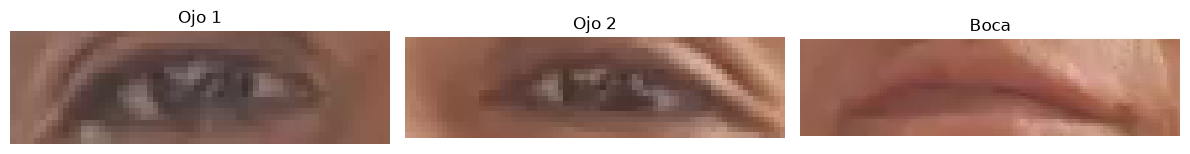

In [30]:
import mediapipe as mp
import matplotlib.pyplot as plt

# BGR -> RGB para MediaPipe
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=frame_rgb
)

resultado = detector.detect(mp_image)

if not resultado.face_landmarks:
    print("No se detectó rostro en este fotograma.")

else:
    landmarks = resultado.face_landmarks[0]

    ojo1, ojo2, bbox1, bbox2 = recortar_ojos(
        frame,
        landmarks
    )

    boca, bbox_boca = recortar_boca(
        frame,
        landmarks
    )

    print("=== RECORTES ===")
    print("Ojo 1:", None if ojo1 is None else ojo1.shape)
    print("Ojo 2:", None if ojo2 is None else ojo2.shape)
    print("Boca :", None if boca is None else boca.shape)

    print("\n=== BOUNDING BOXES ===")
    print("Ojo 1:", bbox1)
    print("Ojo 2:", bbox2)
    print("Boca :", bbox_boca)

    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(
        cv2.cvtColor(ojo1, cv2.COLOR_BGR2RGB)
    )
    axes[0].set_title("Ojo 1")
    axes[0].axis("off")

    axes[1].imshow(
        cv2.cvtColor(ojo2, cv2.COLOR_BGR2RGB)
    )
    axes[1].set_title("Ojo 2")
    axes[1].axis("off")

    axes[2].imshow(
        cv2.cvtColor(boca, cv2.COLOR_BGR2RGB)
    )
    axes[2].set_title("Boca")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [31]:
# ============================================================
# PRIMERA INFERENCIA REAL SOBRE UN FOTOGRAMA
# ============================================================

# T1 - ojo 1
res_ojo1 = inferir_t1_onnx(
    ojo1,
    sesion_t1
)

# T1 - ojo 2
res_ojo2 = inferir_t1_onnx(
    ojo2,
    sesion_t1
)

# Promedio de probabilidad de cierre de ambos ojos
p_cerrado_frame = (
    res_ojo1["p_cerrado"] +
    res_ojo2["p_cerrado"]
) / 2.0

# T2 - boca
res_boca = inferir_t2_onnx(
    boca,
    sesion_t2
)

print("=== T1 - ESTADO OCULAR ===")

print(
    f"Ojo 1 | "
    f"logit={res_ojo1['logit']:.4f} | "
    f"P(abierto)={res_ojo1['p_abierto']:.4f} | "
    f"P(cerrado)={res_ojo1['p_cerrado']:.4f}"
)

print(
    f"Ojo 2 | "
    f"logit={res_ojo2['logit']:.4f} | "
    f"P(abierto)={res_ojo2['p_abierto']:.4f} | "
    f"P(cerrado)={res_ojo2['p_cerrado']:.4f}"
)

print(
    f"\nP(cerrado) promedio del fotograma = "
    f"{p_cerrado_frame:.4f}"
)

print("\n=== T2 - BOSTEZO ===")

print(
    f"logit={res_boca['logit']:.4f} | "
    f"P(yawn)={res_boca['p_yawn']:.4f}"
)

=== T1 - ESTADO OCULAR ===
Ojo 1 | logit=1.3596 | P(abierto)=0.7957 | P(cerrado)=0.2043
Ojo 2 | logit=0.9101 | P(abierto)=0.7130 | P(cerrado)=0.2870

P(cerrado) promedio del fotograma = 0.2456

=== T2 - BOSTEZO ===
logit=-3.2065 | P(yawn)=0.0389


In [32]:
import inspect

funciones = [
    "punto_px",
    "dist",
    "calcular_ear_un_ojo",
    "calcular_mar"
]

print("=== FUNCIONES GEOMÉTRICAS DISPONIBLES ===\n")

for nombre in funciones:
    f = globals().get(nombre)

    if f is None:
        print(f"{nombre}: NO DEFINIDA")
    else:
        print(f"{nombre}: OK")

        try:
            print("Firma:", inspect.signature(f))
        except:
            pass

        try:
            print(inspect.getsource(f))
        except:
            print("(No se pudo mostrar el código fuente)")

        print("-" * 70)

=== FUNCIONES GEOMÉTRICAS DISPONIBLES ===

punto_px: NO DEFINIDA
dist: NO DEFINIDA
calcular_ear_un_ojo: OK
Firma: (landmarks, indices, w, h)
def calcular_ear_un_ojo(landmarks, indices, w, h):
    p = [np.array([landmarks[i].x*w, landmarks[i].y*h]) for i in indices]
    vertical = (np.linalg.norm(p[1]-p[5]) + np.linalg.norm(p[2]-p[4])) / 2
    horizontal = np.linalg.norm(p[0]-p[3])
    return vertical / horizontal

----------------------------------------------------------------------
calcular_mar: OK
Firma: (landmarks, w, h)
def calcular_mar(landmarks, w, h):
    def punto(idx): return np.array([landmarks[idx].x*w, landmarks[idx].y*h])
    horizontal = np.linalg.norm(punto(BOCA["izq"]) - punto(BOCA["der"]))
    v1 = np.linalg.norm(punto(BOCA["sup_ext"]) - punto(BOCA["inf_ext"]))
    v2 = np.linalg.norm(punto(BOCA["sup1"]) - punto(BOCA["inf1"]))
    v3 = np.linalg.norm(punto(BOCA["sup2"]) - punto(BOCA["inf2"]))
    return (v1+v2+v3) / (3*horizontal)

------------------------------------

In [33]:
# ============================================================
# UMBRALES GEOMÉTRICOS CALIBRADOS EN C
# ============================================================

UMBRAL_EAR = 0.1404
UMBRAL_MAR = 0.1624

# Puntos usados para EAR
OJO_IZQ_EAR = [33, 160, 158, 133, 153, 144]
OJO_DER_EAR = [362, 385, 387, 263, 373, 380]

h, w = frame.shape[:2]

# ============================================================
# EAR
# ============================================================

ear_izq = calcular_ear_un_ojo(
    landmarks,
    OJO_IZQ_EAR,
    w,
    h
)

ear_der = calcular_ear_un_ojo(
    landmarks,
    OJO_DER_EAR,
    w,
    h
)

# EAR único del fotograma
ear_frame = (ear_izq + ear_der) / 2.0

# Decisión geométrica:
# 1 = cerrado
# 0 = abierto
d_ear = int(ear_frame < UMBRAL_EAR)


# ============================================================
# MAR
# ============================================================

mar_frame = calcular_mar(
    landmarks,
    w,
    h
)

# Decisión geométrica:
# 1 = bostezo
# 0 = no bostezo
d_mar = int(mar_frame > UMBRAL_MAR)


# ============================================================
# FUSIÓN O2
# ============================================================

score_ojo = (
    0.5 * p_cerrado_frame
    + 0.5 * d_ear
)

score_bostezo = (
    0.5 * res_boca["p_yawn"]
    + 0.5 * d_mar
)


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("=== GEOMETRÍA ===")

print(f"EAR ojo izq : {ear_izq:.4f}")
print(f"EAR ojo der : {ear_der:.4f}")
print(f"EAR promedio: {ear_frame:.4f}")
print(f"D(EAR)      : {d_ear}")

print()

print(f"MAR          : {mar_frame:.4f}")
print(f"D(MAR)       : {d_mar}")


print("\n=== CNN ===")

print(f"P(cerrado)   : {p_cerrado_frame:.4f}")
print(f"P(yawn)      : {res_boca['p_yawn']:.4f}")


print("\n=== FUSIÓN O2 ===")

print(f"Score ojo     : {score_ojo:.4f}")
print(f"Score bostezo : {score_bostezo:.4f}")

=== GEOMETRÍA ===
EAR ojo izq : 0.2522
EAR ojo der : 0.2233
EAR promedio: 0.2377
D(EAR)      : 0

MAR          : 0.1553
D(MAR)       : 0

=== CNN ===
P(cerrado)   : 0.2456
P(yawn)      : 0.0389

=== FUSIÓN O2 ===
Score ojo     : 0.1228
Score bostezo : 0.0195


In [34]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
from pathlib import Path
from time import perf_counter

RUTA_C1 = Path("../data/raw/calibracion_C1.mp4")

filas = []

cap = cv2.VideoCapture(str(RUTA_C1))

fps = cap.get(cv2.CAP_PROP_FPS)
n_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("=== PROCESANDO C1 ===")
print(f"FPS: {fps:.2f}")
print(f"Frames esperados: {n_frames_video}")
print()

frame_idx = 0
inicio = perf_counter()

while True:

    ok, frame_actual = cap.read()

    if not ok:
        break

    # --------------------------------------------------------
    # MEDIAPIPE
    # --------------------------------------------------------

    rgb = cv2.cvtColor(
        frame_actual,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    resultado_frame = detector.detect(mp_image)

    # --------------------------------------------------------
    # SI NO HAY ROSTRO
    # --------------------------------------------------------

    if not resultado_frame.face_landmarks:

        filas.append({
            "persona": "C1",
            "frame": frame_idx,
            "deteccion_rostro": 0,
            "p_cerrado_ojo1": np.nan,
            "p_cerrado_ojo2": np.nan,
            "p_cerrado_frame": np.nan,
            "p_yawn": np.nan
        })

        frame_idx += 1
        continue

    landmarks_frame = resultado_frame.face_landmarks[0]

    # --------------------------------------------------------
    # RECORTES
    # --------------------------------------------------------

    ojo1_c, ojo2_c, _, _ = recortar_ojos(
        frame_actual,
        landmarks_frame
    )

    boca_c, _ = recortar_boca(
        frame_actual,
        landmarks_frame
    )

    # Si algún recorte falla
    if (
        ojo1_c is None
        or ojo2_c is None
        or boca_c is None
        or ojo1_c.size == 0
        or ojo2_c.size == 0
        or boca_c.size == 0
    ):

        filas.append({
            "persona": "C1",
            "frame": frame_idx,
            "deteccion_rostro": 0,
            "p_cerrado_ojo1": np.nan,
            "p_cerrado_ojo2": np.nan,
            "p_cerrado_frame": np.nan,
            "p_yawn": np.nan
        })

        frame_idx += 1
        continue

    # --------------------------------------------------------
    # T1 - AMBOS OJOS
    # --------------------------------------------------------

    r1 = inferir_t1_onnx(
        ojo1_c,
        sesion_t1
    )

    r2 = inferir_t1_onnx(
        ojo2_c,
        sesion_t1
    )

    p_cerrado_1 = r1["p_cerrado"]
    p_cerrado_2 = r2["p_cerrado"]

    p_cerrado_prom = (
        p_cerrado_1 +
        p_cerrado_2
    ) / 2.0

    # --------------------------------------------------------
    # T2 - BOCA
    # --------------------------------------------------------

    rb = inferir_t2_onnx(
        boca_c,
        sesion_t2
    )

    p_yawn = rb["p_yawn"]

    # --------------------------------------------------------
    # GUARDAR
    # --------------------------------------------------------

    filas.append({
        "persona": "C1",
        "frame": frame_idx,
        "deteccion_rostro": 1,
        "p_cerrado_ojo1": p_cerrado_1,
        "p_cerrado_ojo2": p_cerrado_2,
        "p_cerrado_frame": p_cerrado_prom,
        "p_yawn": p_yawn
    })

    frame_idx += 1

    # Progreso
    if frame_idx % 500 == 0:
        print(
            f"{frame_idx}/{n_frames_video} "
            f"frames procesados..."
        )

cap.release()

tiempo = perf_counter() - inicio

df_cnn_c1 = pd.DataFrame(filas)

print("\n=== RESULTADO C1 ===")
print("Frames procesados:", len(df_cnn_c1))
print(
    "Rostros detectados:",
    int(df_cnn_c1["deteccion_rostro"].sum())
)
print(
    "Frames sin rostro:",
    int((df_cnn_c1["deteccion_rostro"] == 0).sum())
)

print(f"Tiempo total: {tiempo:.2f} s")

print("\n=== ESTADÍSTICAS CNN ===")

print(
    df_cnn_c1[
        [
            "p_cerrado_frame",
            "p_yawn"
        ]
    ].describe()
)

# Guardar provisionalmente
salida = Path(
    "../results/calibracion_cnn_C1.csv"
)

df_cnn_c1.to_csv(
    salida,
    index=False
)

print("\nGuardado en:", salida)

=== PROCESANDO C1 ===
FPS: 30.01
Frames esperados: 3627

500/3627 frames procesados...
1000/3627 frames procesados...
1500/3627 frames procesados...
2000/3627 frames procesados...
2500/3627 frames procesados...
3000/3627 frames procesados...
3500/3627 frames procesados...

=== RESULTADO C1 ===
Frames procesados: 3627
Rostros detectados: 3627
Frames sin rostro: 0
Tiempo total: 1518.36 s

=== ESTADÍSTICAS CNN ===
       p_cerrado_frame       p_yawn
count      3627.000000  3627.000000
mean          0.376603     0.166631
std           0.156822     0.276688
min           0.032706     0.003466
25%           0.261182     0.033169
50%           0.373518     0.056543
75%           0.490919     0.107204
max           0.825591     0.999119

Guardado en: ..\results\calibracion_cnn_C1.csv


In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# CARGAR GT
# ============================================================

ruta_gt = Path("../results/calibracion_ear_mar.csv")
df_gt = pd.read_csv(ruta_gt)

# ============================================================
# EXTRAER C1
# ============================================================

df_gt_c1 = df_gt[
    df_gt["persona"] == "calibracion_C1"
].copy()

# Normalizar nombre para que coincida con df_cnn_c1
df_gt_c1["persona"] = "C1"

print("Filas GT C1:", len(df_gt_c1))
print("Filas CNN C1:", len(df_cnn_c1))

# ============================================================
# MERGE POR PERSONA + FRAME
# ============================================================

df_check_c1 = df_gt_c1.merge(
    df_cnn_c1,
    on=["persona", "frame"],
    how="inner",
    validate="one_to_one"
)

print("Filas después del merge:", len(df_check_c1))

# Verificación de alineación
assert len(df_check_c1) == 3627, (
    f"Se esperaban 3627 filas y se obtuvieron "
    f"{len(df_check_c1)}"
)

# ============================================================
# T1
# ============================================================

print("\n=== T1: P(cerrado) SEGÚN CIERRE REAL ===")

print(
    df_check_c1
    .groupby("cierre_real")["p_cerrado_frame"]
    .agg([
        "count",
        "mean",
        "std",
        "median",
        "min",
        "max"
    ])
)

# ============================================================
# T2
# ============================================================

print("\n=== T2: P(yawn) SEGÚN BOSTEZO REAL ===")

print(
    df_check_c1
    .groupby("bostezo_real")["p_yawn"]
    .agg([
        "count",
        "mean",
        "std",
        "median",
        "min",
        "max"
    ])
)

# ============================================================
# COMPROBACIÓN DE SENTIDO
# ============================================================

media_cerrado = df_check_c1.loc[
    df_check_c1["cierre_real"] == 1,
    "p_cerrado_frame"
].mean()

media_abierto = df_check_c1.loc[
    df_check_c1["cierre_real"] == 0,
    "p_cerrado_frame"
].mean()

media_yawn = df_check_c1.loc[
    df_check_c1["bostezo_real"] == 1,
    "p_yawn"
].mean()

media_no_yawn = df_check_c1.loc[
    df_check_c1["bostezo_real"] == 0,
    "p_yawn"
].mean()

print("\n=== COMPROBACIÓN DE SENTIDO ===")

print(
    f"T1 | P(cerrado) con cierre real : "
    f"{media_cerrado:.4f}"
)

print(
    f"T1 | P(cerrado) sin cierre real : "
    f"{media_abierto:.4f}"
)

print()

print(
    f"T2 | P(yawn) con bostezo real   : "
    f"{media_yawn:.4f}"
)

print(
    f"T2 | P(yawn) sin bostezo real   : "
    f"{media_no_yawn:.4f}"
)

print("\n=== VALIDACIÓN AUTOMÁTICA ===")

print(
    "T1 sentido correcto:",
    media_cerrado > media_abierto
)

print(
    "T2 sentido correcto:",
    media_yawn > media_no_yawn
)

Filas GT C1: 3627
Filas CNN C1: 3627
Filas después del merge: 3627

=== T1: P(cerrado) SEGÚN CIERRE REAL ===
             count      mean       std    median       min       max
cierre_real                                                         
0             2421  0.345743  0.160163  0.335732  0.032706  0.825591
1             1206  0.438553  0.129352  0.432352  0.160031  0.791002

=== T2: P(yawn) SEGÚN BOSTEZO REAL ===
              count      mean       std    median       min       max
bostezo_real                                                         
0              3125  0.065489  0.064851  0.049078  0.003466  0.855110
1               502  0.796249  0.258526  0.934397  0.049381  0.999119

=== COMPROBACIÓN DE SENTIDO ===
T1 | P(cerrado) con cierre real : 0.4386
T1 | P(cerrado) sin cierre real : 0.3457

T2 | P(yawn) con bostezo real   : 0.7962
T2 | P(yawn) sin bostezo real   : 0.0655

=== VALIDACIÓN AUTOMÁTICA ===
T1 sentido correcto: True
T2 sentido correcto: True


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
from pathlib import Path
from time import perf_counter


def procesar_calibracion_cnn(persona, ruta_video, archivo_salida):

    filas = []

    cap = cv2.VideoCapture(str(ruta_video))

    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir: {ruta_video}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"=== PROCESANDO {persona} ===")
    print(f"Video: {ruta_video}")
    print(f"FPS: {fps:.2f}")
    print(f"Frames esperados: {n_frames_video}")
    print()

    frame_idx = 0
    inicio = perf_counter()

    while True:

        ok, frame_actual = cap.read()

        if not ok:
            break

        # ====================================================
        # MEDIAPIPE
        # ====================================================

        rgb = cv2.cvtColor(
            frame_actual,
            cv2.COLOR_BGR2RGB
        )

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        resultado_frame = detector.detect(mp_image)

        # ====================================================
        # SIN ROSTRO
        # ====================================================

        if not resultado_frame.face_landmarks:

            filas.append({
                "persona": persona,
                "frame": frame_idx,
                "deteccion_rostro": 0,
                "p_cerrado_ojo1": np.nan,
                "p_cerrado_ojo2": np.nan,
                "p_cerrado_frame": np.nan,
                "p_yawn": np.nan
            })

            frame_idx += 1
            continue

        landmarks_frame = resultado_frame.face_landmarks[0]

        # ====================================================
        # RECORTES
        # ====================================================

        ojo1_c, ojo2_c, _, _ = recortar_ojos(
            frame_actual,
            landmarks_frame
        )

        boca_c, _ = recortar_boca(
            frame_actual,
            landmarks_frame
        )

        # ====================================================
        # VALIDAR RECORTES
        # ====================================================

        if (
            ojo1_c is None
            or ojo2_c is None
            or boca_c is None
            or ojo1_c.size == 0
            or ojo2_c.size == 0
            or boca_c.size == 0
        ):

            filas.append({
                "persona": persona,
                "frame": frame_idx,
                "deteccion_rostro": 0,
                "p_cerrado_ojo1": np.nan,
                "p_cerrado_ojo2": np.nan,
                "p_cerrado_frame": np.nan,
                "p_yawn": np.nan
            })

            frame_idx += 1
            continue

        # ====================================================
        # T1
        # ====================================================

        r1 = inferir_t1_onnx(
            ojo1_c,
            sesion_t1
        )

        r2 = inferir_t1_onnx(
            ojo2_c,
            sesion_t1
        )

        p_cerrado_1 = r1["p_cerrado"]
        p_cerrado_2 = r2["p_cerrado"]
        p_cerrado_prom = (
            p_cerrado_1 +
            p_cerrado_2
        ) / 2.0
        # ====================================================
        # T2
        # ====================================================
        rb = inferir_t2_onnx(
            boca_c,
            sesion_t2
        )

        p_yawn = rb["p_yawn"]
        # ====================================================
        # GUARDAR
        # ====================================================
        filas.append({
            "persona": persona,
            "frame": frame_idx,
            "deteccion_rostro": 1,
            "p_cerrado_ojo1": p_cerrado_1,
            "p_cerrado_ojo2": p_cerrado_2,
            "p_cerrado_frame": p_cerrado_prom,
            "p_yawn": p_yawn
        })
        frame_idx += 1
        if frame_idx % 500 == 0:
            print(
                f"{frame_idx}/{n_frames_video} "
                f"frames procesados..."
            )

    cap.release()
    tiempo = perf_counter() - inicio
    df_resultado = pd.DataFrame(filas)

    # ========================================================
    # COMPROBACIONES
    # ========================================================

    print(f"\n=== RESULTADO {persona} ===")
    print("Frames procesados:", len(df_resultado))
    print(
        "Rostros detectados:",
        int(df_resultado["deteccion_rostro"].sum())
    )
    print(
        "Frames sin rostro:",
        int(
            (df_resultado["deteccion_rostro"] == 0).sum()
        )
    )
    print(f"Tiempo total: {tiempo:.2f} s")
    print("\n=== ESTADÍSTICAS CNN ===")
    print(
        df_resultado[
            [
                "p_cerrado_frame",
                "p_yawn"
            ]
        ].describe()
    )
    # ========================================================
    # GUARDAR
    # ========================================================
    df_resultado.to_csv(
        archivo_salida,
        index=False
    )

    print("\nGuardado en:", archivo_salida)
    return df_resultado

In [38]:
df_cnn_c2 = procesar_calibracion_cnn(
    persona="C2",
    ruta_video=Path("../data/raw/calibracion_C2.mp4"),
    archivo_salida=Path("../results/calibracion_cnn_C2.csv")
)

=== PROCESANDO C2 ===
Video: ..\data\raw\calibracion_C2.mp4
FPS: 60.01
Frames esperados: 6144

500/6144 frames procesados...
1000/6144 frames procesados...
1500/6144 frames procesados...
2000/6144 frames procesados...
2500/6144 frames procesados...
3000/6144 frames procesados...
3500/6144 frames procesados...
4000/6144 frames procesados...
4500/6144 frames procesados...
5000/6144 frames procesados...
5500/6144 frames procesados...
6000/6144 frames procesados...

=== RESULTADO C2 ===
Frames procesados: 6144
Rostros detectados: 6144
Frames sin rostro: 0
Tiempo total: 484.92 s

=== ESTADÍSTICAS CNN ===
       p_cerrado_frame       p_yawn
count      6144.000000  6144.000000
mean          0.373531     0.174003
std           0.184103     0.251535
min           0.025938     0.001359
25%           0.230355     0.038499
50%           0.340631     0.076203
75%           0.489189     0.160347
max           0.920390     0.999120

Guardado en: ..\results\calibracion_cnn_C2.csv


In [40]:
df_cnn_c3 = procesar_calibracion_cnn(
    persona="C3",
    ruta_video=Path("../data/raw/calibracion_C3.mp4"),
    archivo_salida=Path("../results/calibracion_cnn_C3.csv")
)

=== PROCESANDO C3 ===
Video: ..\data\raw\calibracion_C3.mp4
FPS: 30.02
Frames esperados: 2956

500/2956 frames procesados...
1000/2956 frames procesados...
1500/2956 frames procesados...
2000/2956 frames procesados...
2500/2956 frames procesados...

=== RESULTADO C3 ===
Frames procesados: 2956
Rostros detectados: 2956
Frames sin rostro: 0
Tiempo total: 175.72 s

=== ESTADÍSTICAS CNN ===
       p_cerrado_frame       p_yawn
count      2956.000000  2956.000000
mean          0.592918     0.088400
std           0.147243     0.170536
min           0.059030     0.001473
25%           0.510819     0.013272
50%           0.607042     0.026106
75%           0.693644     0.059773
max           0.936958     0.956928

Guardado en: ..\results\calibracion_cnn_C3.csv


In [41]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# CONFIGURACIÓN
# ============================================================

UMBRAL_EAR = 0.1404
UMBRAL_MAR = 0.1624

ruta_gt = Path("../results/calibracion_ear_mar.csv")

# ============================================================
# 1. CARGAR GT
# ============================================================

df_gt = pd.read_csv(ruta_gt)

# Normalizar nombres:
# calibracion_C1 -> C1
# calibracion_C2 -> C2
# calibracion_C3 -> C3
df_gt["persona"] = (
    df_gt["persona"]
    .str.replace("calibracion_", "", regex=False)
)

# ============================================================
# 2. CARGAR CNN
# ============================================================

df_c1 = pd.read_csv("../results/calibracion_cnn_C1.csv")
df_c2 = pd.read_csv("../results/calibracion_cnn_C2.csv")
df_c3 = pd.read_csv("../results/calibracion_cnn_C3.csv")

df_cnn = pd.concat(
    [df_c1, df_c2, df_c3],
    ignore_index=True
)

print("=== TAMAÑOS ===")
print("GT :", len(df_gt))
print("CNN:", len(df_cnn))

# ============================================================
# 3. VALIDACIONES
# ============================================================

assert len(df_gt) == 12727
assert len(df_cnn) == 12727

assert not df_gt.duplicated(
    ["persona", "frame"]
).any()

assert not df_cnn.duplicated(
    ["persona", "frame"]
).any()

# ============================================================
# 4. UNIR
# ============================================================

df_cal = df_gt.merge(
    df_cnn,
    on=["persona", "frame"],
    how="inner",
    validate="one_to_one"
)

print("Filas después del merge:", len(df_cal))

assert len(df_cal) == 12727

# ============================================================
# 5. COMPROBAR FALTANTES
# ============================================================

columnas_clave = [
    "ear",
    "mar",
    "cierre_real",
    "bostezo_real",
    "p_cerrado_frame",
    "p_yawn"
]

print(
    "\nNaN por columna:\n",
    df_cal[columnas_clave].isna().sum()
)

assert df_cal[columnas_clave].isna().sum().sum() == 0

# ============================================================
# 6. DECISIONES GEOMÉTRICAS
# ============================================================

df_cal["d_ear"] = (
    df_cal["ear"] < UMBRAL_EAR
).astype(int)

df_cal["d_mar"] = (
    df_cal["mar"] > UMBRAL_MAR
).astype(int)

# ============================================================
# 7. SCORES DE FUSIÓN
# ============================================================

df_cal["score_ojo"] = (
    0.5 * df_cal["p_cerrado_frame"]
    + 0.5 * df_cal["d_ear"]
)

df_cal["score_bostezo"] = (
    0.5 * df_cal["p_yawn"]
    + 0.5 * df_cal["d_mar"]
)

# ============================================================
# 8. FUNCIÓN PARA ENCONTRAR UMBRAL QUE MAXIMIZA F1
# ============================================================

def calibrar_umbral_f1(y_true, scores):

    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        scores
    )

    # El último precision/recall no tiene threshold asociado
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    f1 = (
        2 * precision_t * recall_t
        / (precision_t + recall_t + 1e-12)
    )

    idx = np.argmax(f1)

    mejor_umbral = float(thresholds[idx])

    y_pred = (
        scores >= mejor_umbral
    ).astype(int)

    p = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    r = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "umbral": mejor_umbral,
        "precision": p,
        "recall": r,
        "f1": f,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

# ============================================================
# 9. CALIBRAR TAU OJO
# ============================================================

resultado_ojo = calibrar_umbral_f1(
    df_cal["cierre_real"],
    df_cal["score_ojo"]
)

# ============================================================
# 10. CALIBRAR TAU BOSTEZO
# ============================================================

resultado_bostezo = calibrar_umbral_f1(
    df_cal["bostezo_real"],
    df_cal["score_bostezo"]
)

# ============================================================
# 11. MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("TAU OJO")
print("=" * 60)

for k, v in resultado_ojo.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("\n" + "=" * 60)
print("TAU BOSTEZO")
print("=" * 60)

for k, v in resultado_bostezo.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

# ============================================================
# 12. GUARDAR RESULTADOS
# ============================================================

df_umbral_fusion = pd.DataFrame([
    {
        "evento": "cierre_ocular",
        "tau": resultado_ojo["umbral"],
        "precision": resultado_ojo["precision"],
        "recall": resultado_ojo["recall"],
        "f1": resultado_ojo["f1"],
        "TP": resultado_ojo["TP"],
        "FP": resultado_ojo["FP"],
        "FN": resultado_ojo["FN"],
        "TN": resultado_ojo["TN"],
        "n_frames_C": len(df_cal)
    },
    {
        "evento": "bostezo",
        "tau": resultado_bostezo["umbral"],
        "precision": resultado_bostezo["precision"],
        "recall": resultado_bostezo["recall"],
        "f1": resultado_bostezo["f1"],
        "TP": resultado_bostezo["TP"],
        "FP": resultado_bostezo["FP"],
        "FN": resultado_bostezo["FN"],
        "TN": resultado_bostezo["TN"],
        "n_frames_C": len(df_cal)
    }
])

df_umbral_fusion.to_csv(
    "../results/umbrales_fusion_O2.csv",
    index=False
)

df_cal.to_csv(
    "../results/calibracion_fusion_completa.csv",
    index=False
)

print("\nArchivos guardados:")
print("../results/umbrales_fusion_O2.csv")
print("../results/calibracion_fusion_completa.csv")

=== TAMAÑOS ===
GT : 12727
CNN: 12727
Filas después del merge: 12727

NaN por columna:
 ear                0
mar                0
cierre_real        0
bostezo_real       0
p_cerrado_frame    0
p_yawn             0
dtype: int64

TAU OJO
umbral: 0.580015
precision: 0.626856
recall: 0.931066
f1: 0.749260
TN: 9345
FP: 1206
FN: 150
TP: 2026

TAU BOSTEZO
umbral: 0.585053
precision: 0.892170
recall: 0.925214
f1: 0.908392
TN: 11166
FP: 157
FN: 105
TP: 1299

Archivos guardados:
../results/umbrales_fusion_O2.csv
../results/calibracion_fusion_completa.csv


In [42]:
print("=== UMBRALES FINALES DE FUSIÓN O2 ===")

print("\nOJO")
print(f"tau_ojo   = {resultado_ojo['umbral']:.6f}")
print(f"precision = {resultado_ojo['precision']:.6f}")
print(f"recall    = {resultado_ojo['recall']:.6f}")
print(f"F1        = {resultado_ojo['f1']:.6f}")
print(
    f"TP={resultado_ojo['TP']} | "
    f"FP={resultado_ojo['FP']} | "
    f"FN={resultado_ojo['FN']} | "
    f"TN={resultado_ojo['TN']}"
)

print("\nBOSTEZO")
print(f"tau_bostezo = {resultado_bostezo['umbral']:.6f}")
print(f"precision   = {resultado_bostezo['precision']:.6f}")
print(f"recall      = {resultado_bostezo['recall']:.6f}")
print(f"F1          = {resultado_bostezo['f1']:.6f}")
print(
    f"TP={resultado_bostezo['TP']} | "
    f"FP={resultado_bostezo['FP']} | "
    f"FN={resultado_bostezo['FN']} | "
    f"TN={resultado_bostezo['TN']}"
)

=== UMBRALES FINALES DE FUSIÓN O2 ===

OJO
tau_ojo   = 0.580015
precision = 0.626856
recall    = 0.931066
F1        = 0.749260
TP=2026 | FP=1206 | FN=150 | TN=9345

BOSTEZO
tau_bostezo = 0.585053
precision   = 0.892170
recall      = 0.925214
F1          = 0.908392
TP=1299 | FP=157 | FN=105 | TN=11166


In [43]:
# ============================================================
# PARÁMETROS DEFINITIVOS DE T3
# CONGELADOS ANTES DE EVALUAR G
# ============================================================

# Geometría calibrada exclusivamente con C
UMBRAL_EAR = 0.1404
UMBRAL_MAR = 0.1624

# Fusión O2 calibrada exclusivamente con C
TAU_OJO = 0.580015
TAU_BOSTEZO = 0.585053

# Persistencia temporal de eventos
DURACION_CIERRE_SEG = 0.5
DURACION_BOSTEZO_SEG = 3.0

# Ventana temporal de PERCLOS
VENTANA_PERCLOS_SEG = 15.0

# Pesos de fusión O2
PESO_CNN = 0.5
PESO_GEOMETRIA = 0.5


print("=== PARÁMETROS T3 CONGELADOS ===")

print(f"EAR threshold      : {UMBRAL_EAR}")
print(f"MAR threshold      : {UMBRAL_MAR}")
print(f"Tau ojo            : {TAU_OJO}")
print(f"Tau bostezo        : {TAU_BOSTEZO}")

print(f"Cierre mínimo      : {DURACION_CIERRE_SEG} s")
print(f"Bostezo mínimo     : {DURACION_BOSTEZO_SEG} s")
print(f"Ventana PERCLOS    : {VENTANA_PERCLOS_SEG} s")

print(f"Peso CNN           : {PESO_CNN}")
print(f"Peso geometría     : {PESO_GEOMETRIA}")

print("\nIMPORTANTE:")
print("- Sin suavizado rolling mean.")
print("- Fallo de rostro reinicia la persistencia temporal.")
print("- PERCLOS se registra, pero no genera un tercer evento.")
print("- Ningún parámetro se ajustará utilizando G.")

=== PARÁMETROS T3 CONGELADOS ===
EAR threshold      : 0.1404
MAR threshold      : 0.1624
Tau ojo            : 0.580015
Tau bostezo        : 0.585053
Cierre mínimo      : 0.5 s
Bostezo mínimo     : 3.0 s
Ventana PERCLOS    : 15.0 s
Peso CNN           : 0.5
Peso geometría     : 0.5

IMPORTANTE:
- Sin suavizado rolling mean.
- Fallo de rostro reinicia la persistencia temporal.
- PERCLOS se registra, pero no genera un tercer evento.
- Ningún parámetro se ajustará utilizando G.


In [44]:
import math


class DetectorPersistencia:
    """
    Confirma un evento únicamente cuando una condición positiva
    permanece de forma continua durante el tiempo mínimo definido.

    Un fallo de detección facial reinicia la racha.
    Solo se emite UNA alerta por cada racha continua.
    """

    def __init__(self, fps, duracion_min_seg, nombre_evento):

        self.fps = float(fps)
        self.duracion_min_seg = float(duracion_min_seg)
        self.nombre_evento = nombre_evento

        # Conversión conservadora segundos -> frames
        self.frames_minimos = math.ceil(
            self.fps * self.duracion_min_seg
        )

        self.reiniciar()


    def reiniciar(self):
        self.contador = 0
        self.frame_inicio_racha = None
        self.alerta_emitida = False


    def actualizar(
        self,
        condicion_positiva,
        frame_idx,
        deteccion_rostro=True
    ):
        """
        Devuelve None si no se genera alerta.

        Cuando se alcanza la persistencia mínima devuelve
        un diccionario con la información de la alerta.
        """

        # ====================================================
        # FALLO DE ROSTRO
        # ====================================================

        if not deteccion_rostro:
            self.reiniciar()
            return None


        # ====================================================
        # CONDICIÓN POSITIVA
        # ====================================================

        if condicion_positiva:

            if self.contador == 0:
                self.frame_inicio_racha = frame_idx

            self.contador += 1

            # Primera vez que alcanza la persistencia requerida
            if (
                self.contador >= self.frames_minimos
                and not self.alerta_emitida
            ):

                self.alerta_emitida = True

                frame_alerta = frame_idx

                return {
                    "evento": self.nombre_evento,
                    "frame_inicio_racha": self.frame_inicio_racha,
                    "frame_alerta": frame_alerta,
                    "tiempo_inicio_racha_s":
                        self.frame_inicio_racha / self.fps,
                    "tiempo_alerta_s":
                        frame_alerta / self.fps,
                    "frames_persistencia":
                        self.contador,
                    "duracion_minima_s":
                        self.duracion_min_seg
                }


        # ====================================================
        # CONDICIÓN NEGATIVA
        # ====================================================

        else:
            self.reiniciar()


        return None

In [45]:
def crear_detectores_temporales(fps):

    return {

        # --------------------
        # O1
        # --------------------

        "O1_cierre": DetectorPersistencia(
            fps=fps,
            duracion_min_seg=DURACION_CIERRE_SEG,
            nombre_evento="cierre_ocular"
        ),

        "O1_bostezo": DetectorPersistencia(
            fps=fps,
            duracion_min_seg=DURACION_BOSTEZO_SEG,
            nombre_evento="bostezo"
        ),

        # --------------------
        # O2
        # --------------------

        "O2_cierre": DetectorPersistencia(
            fps=fps,
            duracion_min_seg=DURACION_CIERRE_SEG,
            nombre_evento="cierre_ocular"
        ),

        "O2_bostezo": DetectorPersistencia(
            fps=fps,
            duracion_min_seg=DURACION_BOSTEZO_SEG,
            nombre_evento="bostezo"
        )
    }


print("Lógica temporal definida correctamente.")

Lógica temporal definida correctamente.


In [46]:
for fps_prueba in [15, 23.99, 29.99, 30.01, 60.01]:

    detectores = crear_detectores_temporales(
        fps_prueba
    )

    print(
        f"FPS={fps_prueba:5.2f} | "
        f"cierre={detectores['O1_cierre'].frames_minimos} frames | "
        f"bostezo={detectores['O1_bostezo'].frames_minimos} frames"
    )

FPS=15.00 | cierre=8 frames | bostezo=45 frames
FPS=23.99 | cierre=12 frames | bostezo=72 frames
FPS=29.99 | cierre=15 frames | bostezo=90 frames
FPS=30.01 | cierre=16 frames | bostezo=91 frames
FPS=60.01 | cierre=31 frames | bostezo=181 frames


In [47]:
# ============================================================
# PRUEBA CONTROLADA - CIERRE OCULAR A 30 FPS
# ============================================================

detector_test = DetectorPersistencia(
    fps=30.0,
    duracion_min_seg=0.5,
    nombre_evento="cierre_ocular"
)

print("Frames mínimos requeridos:",
      detector_test.frames_minimos)

alertas_test = []

# ------------------------------------------------------------
# 1) 14 frames positivos -> NO debe alertar
# frames 0 a 13
# ------------------------------------------------------------

for frame_idx in range(0, 14):

    alerta = detector_test.actualizar(
        condicion_positiva=True,
        frame_idx=frame_idx,
        deteccion_rostro=True
    )

    if alerta is not None:
        alertas_test.append(alerta)


print("\nDespués de 14 positivos:")
print("Contador:", detector_test.contador)
print("Alertas:", len(alertas_test))


# ------------------------------------------------------------
# 2) Frame 14 = fallo de rostro -> debe reiniciar
# ------------------------------------------------------------

alerta = detector_test.actualizar(
    condicion_positiva=False,
    frame_idx=14,
    deteccion_rostro=False
)

print("\nDespués del fallo de rostro:")
print("Contador:", detector_test.contador)
print("Inicio racha:", detector_test.frame_inicio_racha)
print("Alerta emitida:", detector_test.alerta_emitida)


# ------------------------------------------------------------
# 3) Nueva racha: frames 15 a 29 = 15 positivos
# Debe alertar EXACTAMENTE en frame 29
# ------------------------------------------------------------

for frame_idx in range(15, 30):

    alerta = detector_test.actualizar(
        condicion_positiva=True,
        frame_idx=frame_idx,
        deteccion_rostro=True
    )

    if alerta is not None:
        alertas_test.append(alerta)


print("\nDespués de nueva racha de 15 positivos:")
print("Contador:", detector_test.contador)
print("Número de alertas:", len(alertas_test))

if alertas_test:
    print("Última alerta:", alertas_test[-1])


# ------------------------------------------------------------
# 4) Mantener positivo 5 frames más
# NO debe emitir alertas adicionales
# ------------------------------------------------------------

for frame_idx in range(30, 35):

    alerta = detector_test.actualizar(
        condicion_positiva=True,
        frame_idx=frame_idx,
        deteccion_rostro=True
    )

    if alerta is not None:
        alertas_test.append(alerta)


print("\nDespués de mantener la racha:")
print("Contador:", detector_test.contador)
print("Número de alertas:", len(alertas_test))


# ------------------------------------------------------------
# 5) Frame negativo -> termina evento
# ------------------------------------------------------------

detector_test.actualizar(
    condicion_positiva=False,
    frame_idx=35,
    deteccion_rostro=True
)

print("\nDespués de condición negativa:")
print("Contador:", detector_test.contador)
print("Inicio racha:", detector_test.frame_inicio_racha)
print("Alerta emitida:", detector_test.alerta_emitida)


# ------------------------------------------------------------
# RESULTADO AUTOMÁTICO
# ------------------------------------------------------------

ok = (
    detector_test.frames_minimos == 15
    and len(alertas_test) == 1
    and alertas_test[0]["frame_inicio_racha"] == 15
    and alertas_test[0]["frame_alerta"] == 29
)

print("\n=== RESULTADO PRUEBA ===")
print("Lógica temporal correcta:", ok)

Frames mínimos requeridos: 15

Después de 14 positivos:
Contador: 14
Alertas: 0

Después del fallo de rostro:
Contador: 0
Inicio racha: None
Alerta emitida: False

Después de nueva racha de 15 positivos:
Contador: 15
Número de alertas: 1
Última alerta: {'evento': 'cierre_ocular', 'frame_inicio_racha': 15, 'frame_alerta': 29, 'tiempo_inicio_racha_s': 0.5, 'tiempo_alerta_s': 0.9666666666666667, 'frames_persistencia': 15, 'duracion_minima_s': 0.5}

Después de mantener la racha:
Contador: 20
Número de alertas: 1

Después de condición negativa:
Contador: 0
Inicio racha: None
Alerta emitida: False

=== RESULTADO PRUEBA ===
Lógica temporal correcta: True


In [1]:
from pathlib import Path

candidatos = []
for base in [Path("../data"), Path("../results")]:
    if base.exists():
        for f in base.rglob("*.csv"):
            nombre = f.name.lower()
            if any(x in nombre for x in ["calib", "umbral", "conjunto_c", "dataset_c"]):
                candidatos.append(f)

print("CSV encontrados:")
for i, f in enumerate(candidatos):
    print(i, f)

CSV encontrados:
0 ..\results\calibracion_cnn_C1.csv
1 ..\results\calibracion_cnn_C2.csv
2 ..\results\calibracion_cnn_C3.csv
3 ..\results\calibracion_ear_mar.csv
4 ..\results\calibracion_fusion_completa.csv
5 ..\results\umbrales_calibrados.csv
6 ..\results\umbrales_fusion_O2.csv


In [3]:
import pandas as pd
from pathlib import Path

df_geo = pd.read_csv("../results/calibracion_ear_mar.csv")

def contar_eventos(s):
    s = pd.to_numeric(s, errors="coerce").fillna(0).astype(int)
    return int(((s == 1) & (s.shift(fill_value=0) == 0)).sum())

filas = []

for persona in ["C1", "C2", "C3"]:
    df_cnn = pd.read_csv(f"../results/calibracion_cnn_{persona}.csv")
    nombre_geo = f"calibracion_{persona}"
    g = df_geo[df_geo["persona"] == nombre_geo].copy()

    validos = int((df_cnn["deteccion_rostro"] == 1).sum())
    cierres = contar_eventos(g["cierre_real"])
    bostezos = contar_eventos(g["bostezo_real"])

    filas.append({
        "Persona": persona,
        "Fotogramas válidos": validos,
        "Cierres prolongados": cierres,
        "Bostezos": bostezos
    })

tabla_c = pd.DataFrame(filas)
display(tabla_c)

print("Total fotogramas válidos:", tabla_c["Fotogramas válidos"].sum())
print("Total cierres:", tabla_c["Cierres prolongados"].sum())
print("Total bostezos:", tabla_c["Bostezos"].sum())

,Persona,Fotogramas válidos,Cierres prolongados,Bostezos
0,C1,3627,6,3
1,C2,6144,3,3
2,C3,2956,4,2


Total fotogramas válidos: 12727
Total cierres: 13
Total bostezos: 8


In [4]:
from pathlib import Path

extensiones = ["*.mp4", "*.mov", "*.avi", "*.mkv"]

videos = []
for ext in extensiones:
    videos += list(Path("../data").rglob(ext))

for persona in ["C1", "C2", "C3"]:
    print(f"\n{persona}:")
    encontrados = [v for v in videos if persona.lower() in v.name.lower()]
    for v in encontrados:
        print(v)


C1:
..\data\raw\calibracion_C1.mp4

C2:
..\data\raw\calibracion_C2.mp4

C3:
..\data\raw\calibracion_C3.mp4


In [5]:
import cv2
import pandas as pd
from pathlib import Path

datos = [
    ("C1", "../data/raw/calibracion_C1.mp4", 3627, 6, 3),
    ("C2", "../data/raw/calibracion_C2.mp4", 6144, 3, 3),
    ("C3", "../data/raw/calibracion_C3.mp4", 2956, 4, 2)
]

filas = []

for persona, ruta, validos, cierres, bostezos in datos:
    cap = cv2.VideoCapture(ruta)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duracion = frames / fps if fps > 0 else 0
    cap.release()

    minutos = int(duracion // 60)
    segundos = int(round(duracion % 60))
    tiempo = f"{minutos} min {segundos:02d} s"

    filas.append({
        "Persona": persona,
        "Duración": tiempo,
        "Fotogramas válidos": validos,
        "Cierres prolongados": cierres,
        "Bostezos": bostezos
    })

tabla_c = pd.DataFrame(filas)
display(tabla_c)

print("\nTotal fotogramas válidos:", tabla_c["Fotogramas válidos"].sum())
print("Total cierres:", tabla_c["Cierres prolongados"].sum())
print("Total bostezos:", tabla_c["Bostezos"].sum())

,Persona,Duración,Fotogramas válidos,Cierres prolongados,Bostezos
0,C1,2 min 01 s,3627,6,3
1,C2,1 min 42 s,6144,3,3
2,C3,1 min 38 s,2956,4,2



Total fotogramas válidos: 12727
Total cierres: 13
Total bostezos: 8


In [6]:
for persona, ruta, *_ in datos:
    cap = cv2.VideoCapture(ruta)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"{persona}: FPS={fps:.2f} | Frames={frames} | Duración={frames/fps:.2f} s")
    cap.release()

C1: FPS=30.01 | Frames=3627 | Duración=120.88 s
C2: FPS=60.01 | Frames=6144 | Duración=102.39 s
C3: FPS=30.02 | Frames=2956 | Duración=98.47 s


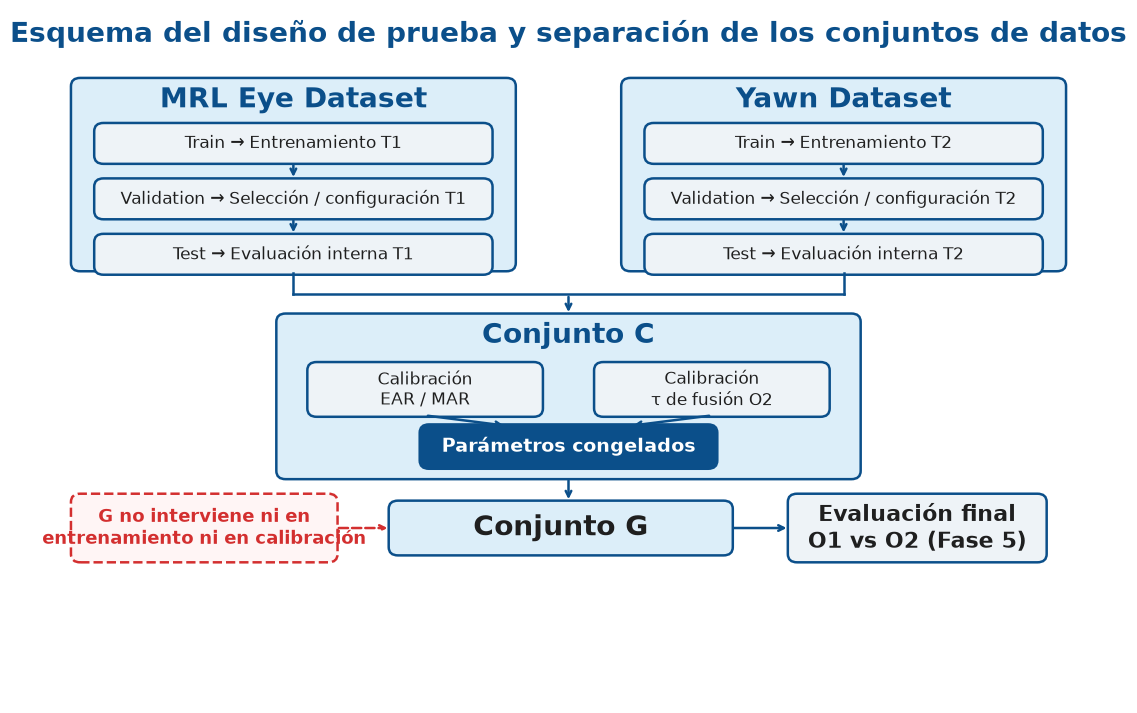

Figura guardada en: ..\results\fig_diseno_prueba_corregida.png


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

fig, ax = plt.subplots(figsize=(14,9))
ax.set_xlim(0,14)
ax.set_ylim(0,10)
ax.axis("off")

azul = "#0B4F8A"
celeste = "#DCEEF9"
gris = "#EEF3F7"
rojo = "#D32F2F"
rosa = "#FFF5F5"

def caja(x,y,w,h,text,fc=gris,ec=azul,fs=11,bold=False,color_texto="#1f1f1f"):
    p = FancyBboxPatch(
        (x,y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor=fc,
        edgecolor=ec,
        linewidth=1.8
    )
    ax.add_patch(p)
    ax.text(
        x+w/2, y+h/2, text,
        ha="center", va="center",
        fontsize=fs,
        fontweight="bold" if bold else "normal",
        color=color_texto
    )

def flecha(x1,y1,x2,y2,color=azul,style="-"):
    ax.annotate(
        "",
        xy=(x2,y2),
        xytext=(x1,y1),
        arrowprops=dict(arrowstyle="->", lw=1.8, color=color, linestyle=style)
    )

# Título
ax.text(
    7, 9.65,
    "Esquema del diseño de prueba y separación de los conjuntos de datos",
    ha="center", va="center",
    fontsize=20, fontweight="bold", color=azul
)

# =========================
# BLOQUE MRL
# =========================
caja(0.6, 6.25, 5.7, 2.75, "", fc=celeste)
ax.text(3.45, 8.7, "MRL Eye Dataset", ha="center", va="center",
        fontsize=20, fontweight="bold", color=azul)

caja(0.9, 7.8, 5.1, 0.55, "Train → Entrenamiento T1", fs=12)
caja(0.9, 7.0, 5.1, 0.55, "Validation → Selección / configuración T1", fs=12)
caja(0.9, 6.2, 5.1, 0.55, "Test → Evaluación interna T1", fs=12)

flecha(3.45, 7.8, 3.45, 7.55)
flecha(3.45, 7.0, 3.45, 6.75)

# =========================
# BLOQUE YAWN
# =========================
caja(7.7, 6.25, 5.7, 2.75, "", fc=celeste)
ax.text(10.55, 8.7, "Yawn Dataset", ha="center", va="center",
        fontsize=20, fontweight="bold", color=azul)

caja(8.0, 7.8, 5.1, 0.55, "Train → Entrenamiento T2", fs=12)
caja(8.0, 7.0, 5.1, 0.55, "Validation → Selección / configuración T2", fs=12)
caja(8.0, 6.2, 5.1, 0.55, "Test → Evaluación interna T2", fs=12)

flecha(10.55, 7.8, 10.55, 7.55)
flecha(10.55, 7.0, 10.55, 6.75)

# =========================
# UNIÓN HACIA C
# =========================
ax.plot([3.45, 3.45], [6.2, 5.9], color=azul, lw=1.8)
ax.plot([10.55, 10.55], [6.2, 5.9], color=azul, lw=1.8)
ax.plot([3.45, 10.55], [5.9, 5.9], color=azul, lw=1.8)
flecha(7.0, 5.9, 7.0, 5.6)

# =========================
# BLOQUE C
# =========================
caja(3.25, 3.25, 7.5, 2.35, "", fc=celeste)
ax.text(7.0, 5.3, "Conjunto C", ha="center", va="center",
        fontsize=20, fontweight="bold", color=azul)

caja(3.65, 4.15, 3.0, 0.75, "Calibración\nEAR / MAR", fs=12)
caja(7.35, 4.15, 3.0, 0.75, "Calibración\nτ de fusión O2", fs=12)

caja(5.1, 3.4, 3.8, 0.6, "Parámetros congelados",
     fc=azul, ec=azul, fs=14, bold=True, color_texto="white")

flecha(5.15, 4.15, 6.2, 4.0)
flecha(8.85, 4.15, 7.8, 4.0)

# =========================
# HACIA G
# =========================
flecha(7.0, 3.25, 7.0, 2.9)

# Caja G
caja(4.7, 2.15, 4.4, 0.75, "Conjunto G", fc=celeste, fs=20, bold=True)

# Evaluación final
caja(9.85, 2.05, 3.3, 0.95, "Evaluación final\nO1 vs O2 (Fase 5)", fs=16, bold=True)
flecha(9.1, 2.525, 9.85, 2.525)

# Advertencia izquierda mejor alineada
caja(0.6, 2.05, 3.4, 0.95,
     "G no interviene ni en\nentrenamiento ni en calibración",
     fc=rosa, ec=rojo, fs=13, bold=True, color_texto=rojo)
for patch in ax.patches[-1:]:
    patch.set_linestyle("--")

flecha(4.0, 2.525, 4.7, 2.525, color=rojo, style="--")

# Guardar
salida = Path("../results/fig_diseno_prueba_corregida.png")
salida.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(salida, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", salida)

In [9]:
from pathlib import Path
import pandas as pd

for f in Path("../results").rglob("*.csv"):
    try:
        df = pd.read_csv(f, nrows=3)
        cols = [c.lower() for c in df.columns]
        if any(x in " ".join(cols) for x in ["pred", "true", "real", "label", "clase"]):
            print(f.name, "→", df.columns.tolist())
    except:
        pass

calibracion_ear_mar.csv → ['persona', 'frame', 'ear', 'mar', 'cierre_real', 'bostezo_real']
calibracion_fusion_completa.csv → ['persona', 'frame', 'ear', 'mar', 'cierre_real', 'bostezo_real', 'deteccion_rostro', 'p_cerrado_ojo1', 'p_cerrado_ojo2', 'p_cerrado_frame', 'p_yawn', 'd_ear', 'd_mar', 'score_ojo', 'score_bostezo']
yawn_metadata.csv → ['ruta', 'archivo', 'clase', 'etiqueta', 'split']
yawn_metadata_dedup.csv → ['ruta', 'archivo', 'clase', 'etiqueta', 'split']


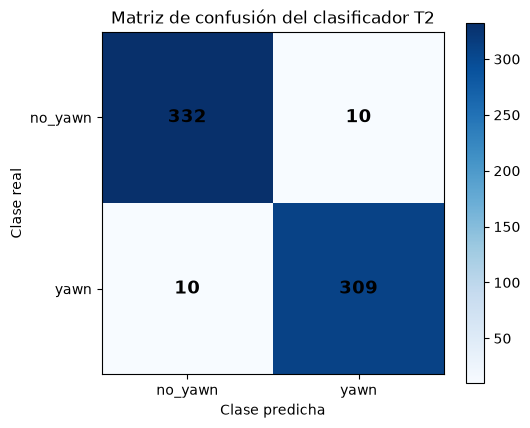

In [10]:
import numpy as np
import matplotlib.pyplot as plt

cm_t2 = np.array([[332,10],
                  [10,309]])

clases = ["no_yawn","yawn"]

fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(cm_t2, cmap="Blues")

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(clases)
ax.set_yticklabels(clases)
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión del clasificador T2")

for i in range(2):
    for j in range(2):
        ax.text(j,i,cm_t2[i,j],ha="center",va="center",
                fontsize=13,fontweight="bold")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("../results/matriz_confusion_T2.png",dpi=300,bbox_inches="tight")
plt.show()

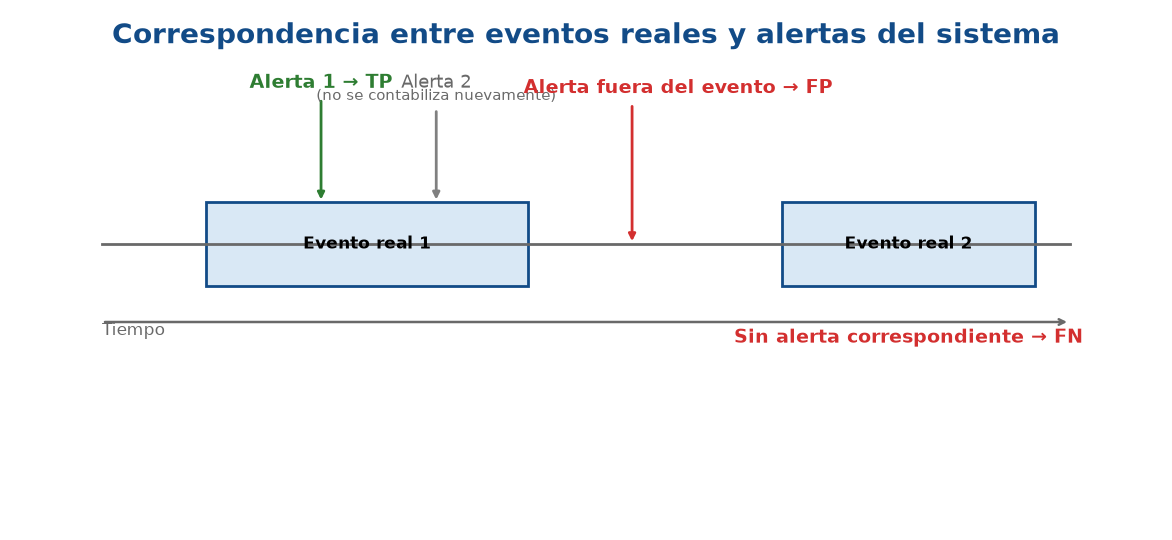

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis("off")

# Título
ax.text(
    50, 95,
    "Correspondencia entre eventos reales y alertas del sistema",
    ha="center", va="center",
    fontsize=20, fontweight="bold", color="#124b87"
)

# Línea principal de eventos
ax.plot([8, 92], [55, 55], color="dimgray", linewidth=2)

# Evento real 1
evento1 = Rectangle(
    (17, 47), 28, 16,
    facecolor="#d9e8f5", edgecolor="#124b87", linewidth=2
)
ax.add_patch(evento1)
ax.text(
    31, 55,
    "Evento real 1",
    ha="center", va="center",
    fontsize=12, fontweight="bold"
)

# Evento real 2
evento2 = Rectangle(
    (67, 47), 22, 16,
    facecolor="#d9e8f5", edgecolor="#124b87", linewidth=2
)
ax.add_patch(evento2)
ax.text(
    78, 55,
    "Evento real 2",
    ha="center", va="center",
    fontsize=12, fontweight="bold"
)

# Alerta 1 = TP
ax.annotate(
    "",
    xy=(27, 63), xytext=(27, 83),
    arrowprops=dict(arrowstyle="-|>", color="#2e7d32", lw=2)
)
ax.text(
    27, 86,
    "Alerta 1 → TP",
    ha="center", va="center",
    fontsize=14, fontweight="bold", color="#2e7d32"
)

# Alerta 2 dentro del mismo evento
ax.annotate(
    "",
    xy=(37, 63), xytext=(37, 81),
    arrowprops=dict(arrowstyle="-|>", color="gray", lw=2)
)
ax.text(
    37, 86,
    "Alerta 2",
    ha="center", va="center",
    fontsize=13, color="dimgray"
)
ax.text(
    37, 82,
    "(no se contabiliza nuevamente)",
    ha="center", va="bottom",
    fontsize=11, color="dimgray"
)

# Alerta fuera del evento = FP
ax.annotate(
    "",
    xy=(54, 55), xytext=(54, 82),
    arrowprops=dict(arrowstyle="-|>", color="#d32f2f", lw=2)
)
ax.text(
    58, 85,
    "Alerta fuera del evento → FP",
    ha="center", va="center",
    fontsize=14, fontweight="bold", color="#d32f2f"
)

# Flecha de tiempo inferior
ax.annotate(
    "",
    xy=(92, 40), xytext=(8, 40),
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.8)
)
ax.text(8, 37.5, "Tiempo", fontsize=12, color="dimgray")

# FN debajo del segundo evento
ax.text(
    78, 37,
    "Sin alerta correspondiente → FN",
    ha="center", va="center",
    fontsize=14, fontweight="bold", color="#d32f2f"
)

plt.tight_layout()
plt.savefig(
    "../results/fase6/figura_correspondencia_eventos_alertas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()